# Gemma 4 31B IT × MMErroR — Publication-Grade Error-Type Classification
## 300-sample balanced diagnostic subset · Question-Comprehension samples excluded · Thinking enabled

**Primary research question.**  
How accurately can `gemma-4-31b-it`, served directly by Google's **Gemini Developer API / Google AI Studio Free tier**, with its strongest documented thinking mode enabled and a long output budget, classify the root cause of erroneous multimodal reasoning on a fixed 300-sample subset of **MMErroR**?

This notebook is designed as a **paper/thesis artifact**, not as an exploratory script. It freezes or records every material choice required to reconstruct the experiment: local Parquet SHA-256, sample IDs, label distribution, selection/order seeds, exact prompt hash, request configuration, model identifier, output budget, parsing policy, retries, checkpoint provenance, and statistical analysis.

### Experimental task

MMErroR's **Error Type Classification (ETC)** setting guarantees that each reasoning chain contains exactly one error and asks the model to classify the error type. The source taxonomy contains four labels, but this experiment uses only the three retained labels A/B/D:

| Label | Official MMErroR category |
|---|---|
| A | Visual Perception Error |
| B | Reasoning Error |
| D | Knowledge Deployment Error |

For this experiment, **all ground-truth `C_Question_Comprehension_Error` examples are excluded before sampling**, as required by the study design.

Crucially, the **prediction space is restricted to the three retained labels A/B/D**. Question Comprehension examples are excluded from sampling and `C_Question_Comprehension_Error` is also removed from the prompt and allowed final-label formats.

### Sampling design

The final set contains exactly:

```text
100 × A_Visual_Perception_Error
100 × B_Reasoning_Error
100 × D_Knowledge_Deployment_Error
-----------------------------------
300 total
```

Within each retained error type, sampling is **proportionally stratified by top-level MMErroR domain**. Exact integer quotas are assigned by the Hamilton/largest-remainder method. Selection inside each `(label, domain)` stratum uses deterministic SHA-256 ranking keyed by the fixed selection seed, avoiding dependence on NumPy/Pandas RNG implementation details.

### Gemma thinking configuration on Google's API

Google's official Gemma-on-Gemini-API documentation states that Gemma 4 thinking is an ON/OFF capability exposed through `thinking_level`: `"high"` enables thinking and `"minimal"` disables it. Therefore this experiment uses:

```text
thinking_level   = "high"
maxOutputTokens  = 32768
```

No NVIDIA-specific `chat_template_kwargs` or OpenAI-compatible reasoning field is used.

### Accuracy-first decoding

This notebook is configured to maximize Gemma 4 judge quality rather than imitate a deterministic temperature-0 baseline. Google's Gemma 4 model card recommends the same standardized sampling configuration across use cases: `temperature=1.0`, `top_p=0.95`, and `top_k=64`. This notebook therefore uses:

```text
temperature       = 1.0
top_p             = 0.95
top_k             = 64
seed              = 42
maxOutputTokens   = 32768
streaming         = False  (generateContent)
thinking_level    = "high"
```

The fixed request seed is retained only as a reproducibility/provenance control; the sampling parameters follow Google's documented Gemma 4 best-practice configuration. The 32K output cap is also checked against the live Google model metadata before any benchmark request is sent.

### Information supplied to Gemma

For each item the request follows the frozen prompt order:

1. the task description;
2. the image;
3. the question;
4. the erroneous reasoning chain;
5. the three retained error-type definitions (A, B, and D);
6. the decision principles and strict final-label format.

The dataset's `correct_answer`, `label`, `domain`, `subdomain`, and `question_id` are **never sent to the model**. They are retained only for auditing and scoring.

### Primary outcome

**Strict error-type accuracy on all 300 selected examples.**

The model is required to end with:

```text
Final label: A
```

(or B/D). Strict parse failures count as incorrect. A relaxed parser is retained only as a diagnostic and never replaces the primary score.

---

### Sources

- Shi et al. (2026), *MMErroR: A Benchmark for Erroneous Reasoning in Vision-Language Models*, ACL 2026:  
  https://aclanthology.org/2026.acl-long.2083/
- Official MMErroR dataset:  
  https://huggingface.co/datasets/s-u-do/mmerror-benchmark
- Official MMErroR evaluation repository:  
  https://github.com/code-here-in/MMerroR-Evaluation
- Google: Run Gemma with the Gemini API:  
  https://ai.google.dev/gemma/docs/core/gemma_on_gemini_api
- Google: Gemma 4 model card / thinking configuration:  
  https://ai.google.dev/gemma/docs/core/model_card_4
- Google: Gemini Developer API pricing (Gemma 4 Free tier):  
  https://ai.google.dev/gemini-api/docs/pricing


### Dataset source

The dataset is loaded locally from the attached Kaggle Parquet artifact at `/kaggle/input/notebooks/vernvern/glimmer/mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet`; this notebook performs no MMErroR dataset download.


## 0. Reproducibility contract

This notebook follows five hard rules:

1. **No silent protocol fallback.** Unsupported request parameters, schema changes, source-count mismatches, or prompt/hash mismatches stop the run.
2. **No content-based retries.** A valid HTTP 200 response is retained exactly once even if it is wrong, malformed, empty, or truncated.
3. **Infrastructure retries only.** Timeouts, rate limits, transient 5xx errors, and connection failures may be retried with fixed backoff.
4. **Checkpoint compatibility is cryptographic.** Prior results are resumed only if the experiment signature matches the exact model, local dataset Parquet SHA-256, 300-item manifest, prompt, decoding configuration, and thinking configuration.
5. **Gold-label isolation.** Ground-truth labels and correct answers are never included in the model request.

A run is labeled **FINAL** only when all 300 items have one retained HTTP-200 model response under the same experiment signature.


In [1]:
# Cell 1 — install only missing lightweight dependencies
import importlib.util
import subprocess
import sys

REQUIRED = {
    "requests": "requests>=2.31",
    "pandas": "pandas>=2.0",
    "pyarrow": "pyarrow>=15",
    "numpy": "numpy>=1.24",
    "PIL": "pillow>=10",
    "sklearn": "scikit-learn>=1.3",
    "matplotlib": "matplotlib>=3.7",
    "tqdm": "tqdm>=4.66",
}

missing = [
    pip_name
    for module_name, pip_name in REQUIRED.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing]
    )
else:
    print("✓ Python dependencies already available.")


✓ Python dependencies already available.


In [2]:
# Cell 2 — imports, frozen constants, seeds, and paths
import os
import io
import re
import json
import math
import time
import base64
import random
import hashlib
import platform
import shutil
import string
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import requests
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
)
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# -------------------- identity --------------------
EXPERIMENT_ID = (
    "MMErroR-ETC300-NoQCE__Gemma4-31B-IT__ThinkingON__"
    "GoogleFreeTier__LocalParquet__BestSampling__Temp1_TopP095_TopK64__MaxTok32768__Seed42__v4"
)

MODEL = "gemma-4-31b-it"
API_PROVIDER = "Google Gemini Developer API"
API_TIER = "Google AI Studio Free tier"
API_VERSION = "v1beta"
API_URL = (
    f"https://generativelanguage.googleapis.com/{API_VERSION}/"
    f"models/{MODEL}:generateContent"
)

# -------------------- source dataset --------------------
# Use the frozen Parquet exported by the attached Kaggle notebook output.
# No MMErroR download is performed by this notebook.
DATASET_PARQUET = Path(
    "/kaggle/input/notebooks/vernvern/glimmer/"
    "mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet"
)
DATASET_SOURCE = str(DATASET_PARQUET)
EXPECTED_TOTAL_ROWS = 1997

LABEL_A = "A_Visual_Perception_Error"
LABEL_B = "B_Reasoning_Error"
LABEL_C = "C_Question_Comprehension_Error"
LABEL_D = "D_Knowledge_Deployment_Error"

EXPECTED_LABEL_COUNTS = {
    LABEL_A: 636,
    LABEL_B: 234,
    LABEL_C: 247,
    LABEL_D: 880,
}

TARGET_LABELS = [LABEL_A, LABEL_B, LABEL_D]
TARGET_PER_LABEL = 100
EXPECTED_N = TARGET_PER_LABEL * len(TARGET_LABELS)

# -------------------- seeds --------------------
MASTER_SEED = 42
SELECTION_SEED = 42
ORDER_SEED = 43
BOOTSTRAP_SEED = 44
REQUEST_SEED = 42

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

# -------------------- model generation protocol --------------------
THINKING_ENABLED = True
TEMPERATURE = 1.0
TOP_P = 0.95
TOP_K = 64
MAX_TOKENS = 32768
STREAM = False

# Accuracy-first Gemma 4 sampling, following Google's model-card best practices.
assert THINKING_ENABLED is True
assert TEMPERATURE == 1.0
assert TOP_P == 0.95
assert TOP_K == 64
assert MAX_TOKENS == 32768
assert REQUEST_SEED == 42

# -------------------- request/retry protocol --------------------
REQUEST_TIMEOUT_S = 1800
MAX_INFRA_ATTEMPTS = 4
RETRYABLE_STATUS = {408, 409, 429, 500, 502, 503, 504}
BACKOFF_SECONDS = [5, 15, 30, 60]
INTER_REQUEST_DELAY_S = 0.0

# -------------------- analysis --------------------
N_BOOTSTRAP = 5000

# -------------------- output --------------------
WORKDIR = Path(
    "/kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4"
)
WORKDIR.mkdir(parents=True, exist_ok=True)

SOURCE_DIR = WORKDIR / "mmerror_source"
PLOTS_DIR = WORKDIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SELECTION_CSV = WORKDIR / "selected_300_manifest.csv"
SELECTION_JSON = WORKDIR / "selected_300_manifest.json"
SELECTION_AUDIT_JSON = WORKDIR / "selection_audit.json"
PROMPT_TXT = WORKDIR / "PROMPT.txt"
RUN_MANIFEST_JSON = WORKDIR / "run_manifest.json"
RAW_RESULTS_JSONL = WORKDIR / "raw_results.jsonl"
API_EVENTS_JSONL = WORKDIR / "api_events.jsonl"
RESULTS_CSV = WORKDIR / "results_300.csv"
SUMMARY_JSON = WORKDIR / "summary_metrics.json"
PER_CLASS_CSV = WORKDIR / "per_class_metrics.csv"
DOMAIN_CSV = WORKDIR / "accuracy_by_domain.csv"
SUBDOMAIN_CSV = WORKDIR / "accuracy_by_subdomain.csv"
METHODS_TXT = WORKDIR / "METHODS.txt"
README_RESULTS = WORKDIR / "README_RESULTS.md"
CITATION_BIB = WORKDIR / "CITATION.bib"

print("=" * 96)
print("EXPERIMENT:", EXPERIMENT_ID)
print("MODEL     :", MODEL)
print("DATASET   :", DATASET_SOURCE)
print("N         :", EXPECTED_N)
print("SEEDS     :", {
    "master": MASTER_SEED,
    "selection": SELECTION_SEED,
    "order": ORDER_SEED,
    "bootstrap": BOOTSTRAP_SEED,
    "request": REQUEST_SEED,
})
print("THINKING  :", THINKING_ENABLED)
print("TEMP      :", TEMPERATURE)
print("TOP_P     :", TOP_P)
print("TOP_K     :", TOP_K)
print("MAX TOKENS:", MAX_TOKENS)
print("OUTPUT    :", WORKDIR)
print("=" * 96)


EXPERIMENT: MMErroR-ETC300-NoQCE__Gemma4-31B-IT__ThinkingON__GoogleFreeTier__LocalParquet__BestSampling__Temp1_TopP095_TopK64__MaxTok32768__Seed42__v4
MODEL     : gemma-4-31b-it
DATASET   : /kaggle/input/notebooks/vernvern/glimmer/mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet
N         : 300
SEEDS     : {'master': 42, 'selection': 42, 'order': 43, 'bootstrap': 44, 'request': 42}
THINKING  : True
TEMP      : 1.0
TOP_P     : 0.95
TOP_K     : 64
MAX TOKENS: 32768
OUTPUT    : /kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4


## 1. Google AI Studio / Gemini API credential handling

This run uses **Google's Gemini Developer API directly**, under the quota/tier associated with the Google AI Studio project (the intended setup here is the **Free tier**). It does not use NVIDIA NIM.

The Google API key is read from an environment variable or Kaggle Secrets and is never printed or written to disk.

Supported secret names, in priority order:

```text
GEMINI_API_KEY_GEMMA4
GEMINI_API_KEY
GOOGLE_API_KEY
```

If none exists, the notebook stops before any API call.


In [3]:
# Cell 3 — retrieve Google Gemini Developer API key without exposing it
def load_google_api_key():
    secret_names = (
        "GEMINI_API_KEY_GEMMA4",
        "GEMINI_API_KEY",
        "GOOGLE_API_KEY",
    )

    # Environment variables first, useful outside Kaggle.
    for env_name in secret_names:
        value = os.environ.get(env_name)
        if value and value.strip():
            return value.strip(), f"env:{env_name}"

    # Kaggle Secrets second.
    try:
        from kaggle_secrets import UserSecretsClient
        client = UserSecretsClient()

        for secret_name in secret_names:
            try:
                value = client.get_secret(secret_name)
            except Exception:
                value = None
            if value and value.strip():
                return value.strip(), f"kaggle_secret:{secret_name}"
    except Exception:
        pass

    raise RuntimeError(
        "No Google Gemini API key found. Add a Kaggle Secret named "
        "'GEMINI_API_KEY_GEMMA4' (preferred), 'GEMINI_API_KEY', or "
        "'GOOGLE_API_KEY'. Obtain the key from Google AI Studio."
    )

GOOGLE_API_KEY, GOOGLE_KEY_SOURCE = load_google_api_key()

print("✓ Google Gemini credential resolved from:", GOOGLE_KEY_SOURCE)
print("✓ Key value is intentionally not displayed.")
print("✓ Provider:", API_PROVIDER)
print("✓ Intended account tier:", API_TIER)

# Live Google model-metadata preflight. This verifies that the hosted model
# still exposes the capabilities assumed by this accuracy-first protocol.
MODEL_METADATA_URL = (
    f"https://generativelanguage.googleapis.com/{API_VERSION}/models/{MODEL}"
)

_model_meta_resp = requests.get(
    MODEL_METADATA_URL,
    headers={"x-goog-api-key": GOOGLE_API_KEY, "Accept": "application/json"},
    timeout=60,
)
if _model_meta_resp.status_code != 200:
    raise RuntimeError(
        "Could not validate live Gemma model metadata before the run. "
        f"HTTP {_model_meta_resp.status_code}: {_model_meta_resp.text[:4000]}"
    )

MODEL_METADATA = _model_meta_resp.json()

if "generateContent" not in set(MODEL_METADATA.get("supportedGenerationMethods") or []):
    raise RuntimeError("Live model metadata does not advertise generateContent support.")
if MODEL_METADATA.get("thinking") is not True:
    raise RuntimeError("Live model metadata does not advertise thinking support.")
if int(MODEL_METADATA.get("outputTokenLimit") or 0) < MAX_TOKENS:
    raise RuntimeError(
        f"Configured maxOutputTokens={MAX_TOKENS} exceeds live model limit "
        f"{MODEL_METADATA.get('outputTokenLimit')}."
    )

# Google currently publishes these values as Gemma 4 best-practice/default sampling.
# Fail loudly if the hosted model metadata changes, rather than silently changing the run.
if float(MODEL_METADATA.get("temperature")) != TEMPERATURE:
    raise RuntimeError(
        f"Live model default temperature changed: {MODEL_METADATA.get('temperature')}"
    )
if abs(float(MODEL_METADATA.get("topP")) - TOP_P) > 1e-12:
    raise RuntimeError(f"Live model topP changed: {MODEL_METADATA.get('topP')}")
if int(MODEL_METADATA.get("topK")) != TOP_K:
    raise RuntimeError(f"Live model topK changed: {MODEL_METADATA.get('topK')}")

print("✓ Live model metadata validated:")
print("  model              :", MODEL_METADATA.get("name"))
print("  input token limit  :", MODEL_METADATA.get("inputTokenLimit"))
print("  output token limit :", MODEL_METADATA.get("outputTokenLimit"))
print("  temperature        :", MODEL_METADATA.get("temperature"))
print("  topP               :", MODEL_METADATA.get("topP"))
print("  topK               :", MODEL_METADATA.get("topK"))
print("  thinking           :", MODEL_METADATA.get("thinking"))



✓ Google Gemini credential resolved from: kaggle_secret:GEMINI_API_KEY_GEMMA4
✓ Key value is intentionally not displayed.
✓ Provider: Google Gemini Developer API
✓ Intended account tier: Google AI Studio Free tier
✓ Live model metadata validated:
  model              : models/gemma-4-31b-it
  input token limit  : 262144
  output token limit : 32768
  temperature        : 1
  topP               : 0.95
  topK               : 64
  thinking           : True


## 2. Load and freeze the local MMErroR Parquet source

This notebook **does not download MMErroR**.

It reads the complete dataset from the attached Kaggle notebook output:

```text
/kaggle/input/notebooks/vernvern/glimmer/mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet
```

For reproducibility, the Parquet file is SHA-256 hashed before sampling. The loader then reconstructs a deterministic local staging copy of the required annotation fields and images under `/kaggle/working`, so the rest of the evaluation pipeline operates on fixed local files.

The source is hard-checked against the expected complete release statistics:

```text
A Visual Perception Error      = 636
B Reasoning Error              = 234
C Question Comprehension Error = 247
D Knowledge Deployment Error   = 880
Total                          = 1997
```

If the Parquet is missing, its schema cannot be resolved, its images cannot be decoded, or these counts differ, execution stops before sampling or API use.


In [4]:
# Cell 4 — load the local Parquet and reconstruct a deterministic staging copy
def sha256_file(path, chunk_size=4 * 1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


if not DATASET_PARQUET.is_file():
    raise FileNotFoundError(
        "Local MMErroR Parquet was not found at the required Kaggle input path:\n"
        f"{DATASET_PARQUET}\n\n"
        "Attach the notebook output "
        "'vernvern/glimmer/mmerror_muse_glimmer_30b_eval' as an input."
    )

DATASET_SOURCE_SHA256 = sha256_file(DATASET_PARQUET)

print("Local dataset:", DATASET_PARQUET)
print("Parquet SHA256:", DATASET_SOURCE_SHA256)

parquet_df = pd.read_parquet(DATASET_PARQUET)

print("Parquet rows   :", len(parquet_df))
print("Parquet columns:", list(parquet_df.columns))

if len(parquet_df) != EXPECTED_TOTAL_ROWS:
    raise RuntimeError(
        f"Parquet rows={len(parquet_df)} != expected {EXPECTED_TOTAL_ROWS}"
    )


def _resolve_column(role, candidates, required=True):
    present = [c for c in candidates if c in parquet_df.columns]
    if not present:
        if required:
            raise RuntimeError(
                f"Could not resolve required '{role}' column. "
                f"Tried {candidates}. Available columns: {list(parquet_df.columns)}"
            )
        return None
    # Prefer the first canonical candidate. The resolved mapping is printed below.
    return present[0]


COLUMN_MAP = {
    "question_id": _resolve_column(
        "question_id", ["question_id", "qid", "id"]
    ),
    "question": _resolve_column(
        "question", ["question", "prompt"]
    ),
    "correct_answer": _resolve_column(
        "correct_answer", ["correct_answer", "gold_answer", "answer"]
    ),
    "error_reason": _resolve_column(
        "error_reason",
        ["error_reason", "erroneous_reasoning", "error_reasoning", "reasoning_chain"],
    ),
    "domain": _resolve_column(
        "domain", ["domain", "category"]
    ),
    "subdomain": _resolve_column(
        "subdomain", ["subdomain", "sub_domain"]
    ),
}

# Resolve the gold label carefully. This Parquet may also contain model predictions,
# so a label-like column is accepted only if its normalized full-dataset counts
# exactly match the expected MMErroR source distribution.
LABEL_ALIASES = {
    "A": LABEL_A,
    "VPE": LABEL_A,
    "A_VISUAL_PERCEPTION_ERROR": LABEL_A,
    "VISUAL_PERCEPTION_ERROR": LABEL_A,
    "VISUAL PERCEPTION ERROR": LABEL_A,
    "B": LABEL_B,
    "RE": LABEL_B,
    "B_REASONING_ERROR": LABEL_B,
    "REASONING_ERROR": LABEL_B,
    "REASONING ERROR": LABEL_B,
    "C": LABEL_C,
    "QCE": LABEL_C,
    "C_QUESTION_COMPREHENSION_ERROR": LABEL_C,
    "QUESTION_COMPREHENSION_ERROR": LABEL_C,
    "QUESTION COMPREHENSION ERROR": LABEL_C,
    "D": LABEL_D,
    "KDE": LABEL_D,
    "D_KNOWLEDGE_DEPLOYMENT_ERROR": LABEL_D,
    "KNOWLEDGE_DEPLOYMENT_ERROR": LABEL_D,
    "KNOWLEDGE DEPLOYMENT ERROR": LABEL_D,
}


def normalize_label_value(value):
    s = str(value).strip()
    key = s.upper()
    if key in LABEL_ALIASES:
        return LABEL_ALIASES[key]
    return s


label_candidates = [
    c for c in [
        "label",
        "gold_label",
        "ground_truth_label",
        "error_type",
        "gold_error_type",
    ]
    if c in parquet_df.columns
]

valid_label_columns = []
for c in label_candidates:
    normalized = parquet_df[c].map(normalize_label_value)
    counts = normalized.value_counts().to_dict()
    if counts == EXPECTED_LABEL_COUNTS:
        valid_label_columns.append(c)

if not valid_label_columns:
    diagnostics = {
        c: parquet_df[c].map(normalize_label_value).value_counts().to_dict()
        for c in label_candidates
    }
    raise RuntimeError(
        "Could not identify the ground-truth label column by the expected "
        f"full-dataset counts. Candidate counts: {diagnostics}"
    )

if len(valid_label_columns) > 1:
    first = parquet_df[valid_label_columns[0]].map(normalize_label_value)
    for other_name in valid_label_columns[1:]:
        other = parquet_df[other_name].map(normalize_label_value)
        if not first.equals(other):
            raise RuntimeError(
                "Multiple non-identical columns match the expected gold-label "
                f"distribution: {valid_label_columns}. Refusing to guess."
            )

COLUMN_MAP["label"] = valid_label_columns[0]

# Image values from Hugging Face/Arrow Parquet are commonly stored as a struct
# {'bytes': ..., 'path': ...}. We also support direct bytes, a real file path,
# base64, or a single image array.
IMAGE_COLUMNS = [
    c for c in [
        "image",
        "image_bytes",
        "image_base64",
        "image_b64",
        "image_path",
        "images",
    ]
    if c in parquet_df.columns
]

if not IMAGE_COLUMNS:
    # Last-resort discovery by column name, still without guessing a specific field.
    IMAGE_COLUMNS = [
        c for c in parquet_df.columns
        if "image" in str(c).lower()
    ]

if not IMAGE_COLUMNS:
    raise RuntimeError(
        "No image-bearing column was found in the Parquet. "
        f"Available columns: {list(parquet_df.columns)}"
    )

print("Resolved schema:")
for k, v in COLUMN_MAP.items():
    print(f"  {k:15s} <- {v}")
print("Image candidates:", IMAGE_COLUMNS)

# Reconstruct the same downstream staging layout used by the evaluation pipeline.
JSON_DIR = SOURCE_DIR / "data" / "jsons"
IMAGE_DIR = SOURCE_DIR / "data" / "images"
JSON_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def _decode_base64_string(s):
    s = str(s).strip()
    if s.startswith("data:image") and "," in s:
        s = s.split(",", 1)[1]
    try:
        return base64.b64decode(s, validate=True)
    except Exception:
        return None


def _save_pil_as_png(im, dest):
    im.load()
    # PNG handles most common modes. Convert unsupported/awkward modes safely.
    if im.mode in {"CMYK", "YCbCr"}:
        im = im.convert("RGB")
    im.save(dest, format="PNG")
    if Path(dest).read_bytes()[:8] != b"\x89PNG\r\n\x1a\n":
        raise RuntimeError(f"Failed to materialize a valid PNG: {dest}")


def _try_materialize_image_value(value, dest, column_name):
    if value is None:
        return False

    # Hugging Face Image feature / Arrow struct.
    if isinstance(value, dict):
        for key in ("bytes", "data", "image_bytes", "content"):
            if key in value and value[key] is not None:
                if _try_materialize_image_value(value[key], dest, column_name):
                    return True
        for key in ("path", "file_path", "filename"):
            if key in value and value[key]:
                if _try_materialize_image_value(value[key], dest, column_name):
                    return True
        return False

    if isinstance(value, (list, tuple)):
        if len(value) == 1:
            return _try_materialize_image_value(value[0], dest, column_name)
        return False

    if isinstance(value, memoryview):
        value = value.tobytes()

    if isinstance(value, (bytes, bytearray)):
        raw = bytes(value)
        try:
            with Image.open(io.BytesIO(raw)) as im:
                _save_pil_as_png(im, dest)
            return True
        except Exception:
            return False

    if isinstance(value, np.ndarray):
        try:
            if value.ndim in (2, 3):
                im = Image.fromarray(value)
                _save_pil_as_png(im, dest)
                return True
            if value.ndim == 1 and value.dtype == np.uint8:
                with Image.open(io.BytesIO(value.tobytes())) as im:
                    _save_pil_as_png(im, dest)
                return True
        except Exception:
            return False
        return False

    if isinstance(value, str):
        s = value.strip()
        if not s:
            return False

        candidate_paths = []
        p = Path(s)
        if p.is_absolute():
            candidate_paths.append(p)
        else:
            candidate_paths.append(DATASET_PARQUET.parent / p)
            candidate_paths.append(p)

        for candidate in candidate_paths:
            if candidate.is_file():
                try:
                    with Image.open(candidate) as im:
                        _save_pil_as_png(im, dest)
                    return True
                except Exception:
                    pass

        if "base64" in column_name.lower() or s.startswith("data:image"):
            raw = _decode_base64_string(s)
            if raw:
                try:
                    with Image.open(io.BytesIO(raw)) as im:
                        _save_pil_as_png(im, dest)
                    return True
                except Exception:
                    return False

    return False


def materialize_row_image(raw_row, qid):
    dest = IMAGE_DIR / f"{qid}.png"
    if dest.is_file():
        # Validate any previously staged file before reusing it.
        if dest.read_bytes()[:8] == b"\x89PNG\r\n\x1a\n":
            return dest
        dest.unlink()

    errors = []
    for col in IMAGE_COLUMNS:
        try:
            if _try_materialize_image_value(raw_row[col], dest, col):
                return dest
        except Exception as e:
            errors.append(f"{col}: {type(e).__name__}: {e}")

    raise RuntimeError(
        f"Could not decode image for {qid}. Tried columns {IMAGE_COLUMNS}. "
        f"Details: {errors[:5]}"
    )


# Build deterministic canonical JSON annotations and PNG files from the Parquet.
# This intentionally stages ALL 1,997 rows so the same hard audit as before remains valid.
for _, raw_row in tqdm(
    parquet_df.iterrows(),
    total=len(parquet_df),
    desc="Staging local MMErroR Parquet",
):
    item = {
        "question_id": str(raw_row[COLUMN_MAP["question_id"]]).strip(),
        "question": str(raw_row[COLUMN_MAP["question"]]),
        "correct_answer": str(raw_row[COLUMN_MAP["correct_answer"]]),
        "error_reason": str(raw_row[COLUMN_MAP["error_reason"]]),
        "label": normalize_label_value(raw_row[COLUMN_MAP["label"]]),
        "domain": str(raw_row[COLUMN_MAP["domain"]]),
        "subdomain": str(raw_row[COLUMN_MAP["subdomain"]]),
    }

    qid = item["question_id"]
    if not qid:
        raise RuntimeError("Encountered an empty question_id in the Parquet.")

    json_path = JSON_DIR / f"{qid}.json"
    json_path.write_text(
        json.dumps(item, ensure_ascii=False, sort_keys=True, indent=2),
        encoding="utf-8",
    )

    materialize_row_image(raw_row, qid)

json_files = sorted(JSON_DIR.glob("*.json"))
image_files = sorted(IMAGE_DIR.glob("*.png"))

print("Staged JSON files :", len(json_files))
print("Staged image files:", len(image_files))

if len(json_files) != EXPECTED_TOTAL_ROWS:
    raise RuntimeError(
        f"Expected {EXPECTED_TOTAL_ROWS} staged JSON annotations, found {len(json_files)}"
    )

if len(image_files) != EXPECTED_TOTAL_ROWS:
    raise RuntimeError(
        f"Expected {EXPECTED_TOTAL_ROWS} staged images, found {len(image_files)}"
    )

print("✓ Local Parquet loaded; no MMErroR network download performed.")
print("✓ Deterministic annotation/image staging complete.")


Local dataset: /kaggle/input/notebooks/vernvern/glimmer/mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet
Parquet SHA256: 3d4c3bded9ce04336c878da6bc1e139362fc915818dcfc72380bfc24eb097edb
Parquet rows   : 1997
Parquet columns: ['question_id', 'question', 'correct_answer', 'error_reason', 'label', 'domain', 'subdomain', 'image_mime', 'image_bytes', 'json_sha256', 'image_sha256']
Resolved schema:
  question_id     <- question_id
  question        <- question
  correct_answer  <- correct_answer
  error_reason    <- error_reason
  domain          <- domain
  subdomain       <- subdomain
  label           <- label
Image candidates: ['image_bytes']


Staging local MMErroR Parquet:   0%|          | 0/1997 [00:00<?, ?it/s]

Staged JSON files : 1997
Staged image files: 1997
✓ Local Parquet loaded; no MMErroR network download performed.
✓ Deterministic annotation/image staging complete.


In [5]:
# Cell 5 — parse and audit every staged MMErroR annotation from the local Parquet
REQUIRED_FIELDS = {
    "question_id",
    "question",
    "correct_answer",
    "error_reason",
    "label",
    "domain",
    "subdomain",
}

rows = []

for json_path in tqdm(json_files, desc="Auditing MMErroR annotations"):
    item = json.loads(json_path.read_text(encoding="utf-8"))

    missing = REQUIRED_FIELDS - set(item)
    if missing:
        raise RuntimeError(
            f"{json_path.name} missing fields: {sorted(missing)}"
        )

    qid = str(item["question_id"]).strip()
    image_path = IMAGE_DIR / f"{qid}.png"

    if not image_path.is_file():
        raise RuntimeError(f"Missing image for {qid}: {image_path}")

    if json_path.stem != qid:
        raise RuntimeError(
            f"JSON filename/question_id mismatch: {json_path.stem} != {qid}"
        )

    rows.append({
        "question_id": qid,
        "question": str(item["question"]),
        "correct_answer": str(item.get("correct_answer", "")),
        "error_reason": str(item["error_reason"]),
        "label": str(item["label"]),
        "domain": str(item["domain"]),
        "subdomain": str(item["subdomain"]),
        "json_path": str(json_path),
        "image_path": str(image_path),
    })

full_df = pd.DataFrame(rows)

if len(full_df) != EXPECTED_TOTAL_ROWS:
    raise RuntimeError(
        f"Parsed rows={len(full_df)} != {EXPECTED_TOTAL_ROWS}"
    )

if full_df["question_id"].nunique() != EXPECTED_TOTAL_ROWS:
    raise RuntimeError("MMErroR question_id values are not unique.")

observed_label_counts = full_df["label"].value_counts().to_dict()

if observed_label_counts != EXPECTED_LABEL_COUNTS:
    raise RuntimeError(
        "MMErroR label counts differ from the frozen ACL-2026 release.\n"
        f"Observed: {observed_label_counts}\n"
        f"Expected: {EXPECTED_LABEL_COUNTS}"
    )

if full_df["domain"].nunique() != 6:
    raise RuntimeError(
        f"Expected 6 top-level domains, found {full_df['domain'].nunique()}"
    )

if full_df["subdomain"].nunique() != 24:
    raise RuntimeError(
        f"Expected 24 subdomains, found {full_df['subdomain'].nunique()}"
    )

audit_table = (
    full_df.groupby(["label", "domain"])
    .size()
    .rename("n")
    .reset_index()
)

display(Markdown("### Source label counts"))
display(
    full_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

display(Markdown("### Source label × domain counts"))
display(audit_table)

print("✓ Full MMErroR source audit PASS.")


Auditing MMErroR annotations:   0%|          | 0/1997 [00:00<?, ?it/s]

### Source label counts

,label,count
0,D_Knowledge_Deployment_Error,880
1,A_Visual_Perception_Error,636
2,C_Question_Comprehension_Error,247
3,B_Reasoning_Error,234


### Source label × domain counts

,label,domain,n
0,A_Visual_Perception_Error,Biology & Healthcare,115
1,A_Visual_Perception_Error,Chemistry & Materials,38
2,A_Visual_Perception_Error,Data & Analytics,59
3,A_Visual_Perception_Error,Earth & Environment,195
4,A_Visual_Perception_Error,Mathematics & Logic,87
5,A_Visual_Perception_Error,Physics & Engineering,142
6,B_Reasoning_Error,Biology & Healthcare,33
7,B_Reasoning_Error,Chemistry & Materials,9
8,B_Reasoning_Error,Data & Analytics,63
9,B_Reasoning_Error,Earth & Environment,38


✓ Full MMErroR source audit PASS.


## 3. Construct the fixed 300-sample evaluation subset

### Why balanced 100/100/100?

The original MMErroR error-type distribution is highly imbalanced: Knowledge Deployment Error is much more common than Reasoning Error. A naïve 300-row random subset would therefore make headline accuracy disproportionately reflect the majority class.

For this diagnostic experiment, the three retained ground-truth classes are sampled equally:

```text
A = 100
B = 100
D = 100
```

This makes the primary result easier to interpret as broad error-diagnosis capability rather than prevalence-weighted majority-class performance.

### Why use a three-class A/B/D decision space?

The study design excludes ground-truth Question Comprehension Error examples. The prompt therefore also excludes that category and asks the judge to classify only among A, B, and D.

### Within-class domain stratification

Each retained class's 100-sample allocation across the six MMErroR domains is proportional to that class's source distribution. Integer quotas are assigned with the Hamilton/largest-remainder method.

Selection and final evaluation order are deterministic SHA-256 rankings keyed by fixed seeds.


In [6]:
# Cell 6 — deterministic proportional stratified selection
def hamilton_allocation(counts: dict, total_to_select: int) -> dict:
    """
    Largest-remainder / Hamilton apportionment.
    counts: {stratum: available_count}
    """
    available_total = sum(counts.values())
    if available_total < total_to_select:
        raise ValueError(
            f"Need {total_to_select} but only {available_total} available."
        )

    exact = {
        k: total_to_select * v / available_total
        for k, v in counts.items()
    }
    alloc = {
        k: int(math.floor(exact[k]))
        for k in counts
    }

    remaining = total_to_select - sum(alloc.values())

    order = sorted(
        counts,
        key=lambda k: (
            -(exact[k] - alloc[k]),
            k,
        ),
    )

    for k in order[:remaining]:
        alloc[k] += 1

    # Capacity safeguard; normally unnecessary because quotas are proportional.
    overflow = {
        k: alloc[k] - counts[k]
        for k in counts
        if alloc[k] > counts[k]
    }
    if overflow:
        raise RuntimeError(f"Hamilton allocation exceeded capacity: {overflow}")

    if sum(alloc.values()) != total_to_select:
        raise RuntimeError("Hamilton allocation did not sum to target.")

    return alloc


def seeded_rank(seed: int, *parts: str) -> str:
    canonical = "|".join([str(seed), *map(str, parts)])
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()


selected_parts = []
quota_rows = []

for label in TARGET_LABELS:
    label_df = full_df[full_df["label"] == label].copy()

    domain_counts = (
        label_df["domain"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    quotas = hamilton_allocation(
        domain_counts,
        TARGET_PER_LABEL,
    )

    for domain, quota in sorted(quotas.items()):
        stratum = label_df[label_df["domain"] == domain].copy()

        stratum["_selection_rank"] = stratum["question_id"].map(
            lambda qid: seeded_rank(
                SELECTION_SEED,
                label,
                domain,
                qid,
            )
        )

        chosen = (
            stratum
            .sort_values(
                ["_selection_rank", "question_id"],
                kind="mergesort",
            )
            .head(quota)
            .drop(columns=["_selection_rank"])
        )

        if len(chosen) != quota:
            raise RuntimeError(
                f"Could not select quota={quota} for {label}/{domain}"
            )

        selected_parts.append(chosen)

        quota_rows.append({
            "label": label,
            "domain": domain,
            "available": int(len(stratum)),
            "quota": int(quota),
        })

selected_df = pd.concat(
    selected_parts,
    ignore_index=True,
)

# Final order is independently deterministic.
selected_df["_order_rank"] = selected_df["question_id"].map(
    lambda qid: seeded_rank(
        ORDER_SEED,
        qid,
    )
)

selected_df = (
    selected_df
    .sort_values(
        ["_order_rank", "question_id"],
        kind="mergesort",
    )
    .drop(columns=["_order_rank"])
    .reset_index(drop=True)
)

selected_df.insert(
    0,
    "evaluation_order",
    np.arange(1, len(selected_df) + 1),
)

# Hard selection gates.
if len(selected_df) != EXPECTED_N:
    raise RuntimeError(
        f"Selected rows={len(selected_df)} != {EXPECTED_N}"
    )

if selected_df["question_id"].nunique() != EXPECTED_N:
    raise RuntimeError("Selected question IDs are not unique.")

if LABEL_C in set(selected_df["label"]):
    raise RuntimeError(
        "Forbidden Question Comprehension Error sample entered Eval300."
    )

expected_selected_counts = {
    LABEL_A: 100,
    LABEL_B: 100,
    LABEL_D: 100,
}

if selected_df["label"].value_counts().to_dict() != expected_selected_counts:
    raise RuntimeError(
        "Selected class counts are not exactly 100/100/100."
    )

quota_df = pd.DataFrame(quota_rows)

display(Markdown("### Final class balance"))
display(
    selected_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="selected")
)

display(Markdown("### Proportional domain quotas within each retained class"))
display(quota_df)

display(Markdown("### Selected 300 — domain distribution"))
display(
    selected_df.groupby(["label", "domain"])
    .size()
    .rename("selected")
    .reset_index()
)

print("✓ Question-Comprehension (C) ground-truth samples excluded.")
print("✓ Exactly 100 A + 100 B + 100 D selected.")
print("✓ Evaluation order deterministically fixed.")


### Final class balance

,label,selected
0,A_Visual_Perception_Error,100
1,D_Knowledge_Deployment_Error,100
2,B_Reasoning_Error,100


### Proportional domain quotas within each retained class

,label,domain,available,quota
0,A_Visual_Perception_Error,Biology & Healthcare,115,18
1,A_Visual_Perception_Error,Chemistry & Materials,38,6
2,A_Visual_Perception_Error,Data & Analytics,59,9
3,A_Visual_Perception_Error,Earth & Environment,195,31
4,A_Visual_Perception_Error,Mathematics & Logic,87,14
5,A_Visual_Perception_Error,Physics & Engineering,142,22
6,B_Reasoning_Error,Biology & Healthcare,33,14
7,B_Reasoning_Error,Chemistry & Materials,9,4
8,B_Reasoning_Error,Data & Analytics,63,27
9,B_Reasoning_Error,Earth & Environment,38,16


### Selected 300 — domain distribution

,label,domain,selected
0,A_Visual_Perception_Error,Biology & Healthcare,18
1,A_Visual_Perception_Error,Chemistry & Materials,6
2,A_Visual_Perception_Error,Data & Analytics,9
3,A_Visual_Perception_Error,Earth & Environment,31
4,A_Visual_Perception_Error,Mathematics & Logic,14
5,A_Visual_Perception_Error,Physics & Engineering,22
6,B_Reasoning_Error,Biology & Healthcare,14
7,B_Reasoning_Error,Chemistry & Materials,4
8,B_Reasoning_Error,Data & Analytics,27
9,B_Reasoning_Error,Earth & Environment,16


✓ Question-Comprehension (C) ground-truth samples excluded.
✓ Exactly 100 A + 100 B + 100 D selected.
✓ Evaluation order deterministically fixed.


In [7]:
# Cell 7 — cryptographically bind the exact selected inputs
manifest_records = []

for row in tqdm(
    selected_df.itertuples(index=False),
    total=len(selected_df),
    desc="Hashing selected inputs",
):
    json_sha = sha256_file(row.json_path)
    image_sha = sha256_file(row.image_path)

    manifest_records.append({
        "evaluation_order": int(row.evaluation_order),
        "question_id": row.question_id,
        "gold_label": row.label,
        "domain": row.domain,
        "subdomain": row.subdomain,
        "json_sha256": json_sha,
        "image_sha256": image_sha,
    })

manifest_json_canonical = json.dumps(
    manifest_records,
    ensure_ascii=False,
    sort_keys=True,
    separators=(",", ":"),
)

SELECTION_MANIFEST_SHA256 = hashlib.sha256(
    manifest_json_canonical.encode("utf-8")
).hexdigest()

pd.DataFrame(manifest_records).to_csv(
    SELECTION_CSV,
    index=False,
)

SELECTION_JSON.write_text(
    json.dumps(
        manifest_records,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

selection_audit = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_source": DATASET_SOURCE,
    "dataset_parquet_sha256": DATASET_SOURCE_SHA256,
    "expected_total_rows": EXPECTED_TOTAL_ROWS,
    "observed_total_rows": len(full_df),
    "expected_label_counts": EXPECTED_LABEL_COUNTS,
    "observed_label_counts": observed_label_counts,
    "excluded_ground_truth_label": LABEL_C,
    "retained_ground_truth_labels": TARGET_LABELS,
    "target_per_retained_label": TARGET_PER_LABEL,
    "selection_seed": SELECTION_SEED,
    "order_seed": ORDER_SEED,
    "sampling_method": (
        "100 per retained label; proportional top-level-domain allocation "
        "via Hamilton method; deterministic SHA256 ranking within strata"
    ),
    "evaluation_order_method": (
        "deterministic SHA256 ranking of question_id using ORDER_SEED"
    ),
    "selected_rows": len(selected_df),
    "selected_unique_ids": int(selected_df["question_id"].nunique()),
    "selected_label_counts": selected_df["label"].value_counts().to_dict(),
    "selection_manifest_sha256": SELECTION_MANIFEST_SHA256,
    "domain_quotas": quota_rows,
}

SELECTION_AUDIT_JSON.write_text(
    json.dumps(selection_audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Selected manifest SHA256:", SELECTION_MANIFEST_SHA256)
print("✓ Exact 300-item dataset identity cryptographically archived.")


Hashing selected inputs:   0%|          | 0/300 [00:00<?, ?it/s]

Selected manifest SHA256: 857235b6fab021251a662ab0bf92fe7ec0158fd8480cb0bf5e479cd82e119f5a
✓ Exact 300-item dataset identity cryptographically archived.


## 4. Frozen ETC prompt

The prompt is the frozen three-class A/B/D judge prompt defined for this experiment.

Ground-truth Question Comprehension Error examples are excluded from sampling, and the prompt likewise exposes only the three retained choices:

- **A — Visual Perception Error**
- **B — Reasoning Error**
- **D — Knowledge Deployment Error**

The prompt states that an error is guaranteed to be present, provides the image, question, erroneous reasoning chain, the three category definitions, decision principles, and a strict final-label format.

Gold label and correct answer are never inserted into the model request.


In [8]:
# Cell 8 — exact frozen prompt and parser
# The full user prompt is kept as one canonical template. The [IMAGE] marker is
# replaced by the actual multimodal image part in the Google request.
SYSTEM_PROMPT = None

USER_PROMPT_TEMPLATE = 'You are given an image, a corresponding question, and a complete reasoning chain that is guaranteed to contain an error.\n\nYour task is to identify the specific error type in the reasoning chain from the predefined error taxonomy.\n\n## Input\n\n### Image\n\n[IMAGE]\n\n### Question\n\n{question}\n\n### Reasoning Chain\n\n{error_reason}\n\n## Error Taxonomy\n\n1. A_Visual_Perception_Error\n   The model makes a mistake in visually interpreting the image, such as:\n\n- Misreading text or numbers (OCR error, e.g., reading "1.0" as "10").\n- Misinterpreting chart or table values (e.g., confusing bar heights).\n- Confusing colors, shapes, positions, or object counts.\n- Mislocating objects (e.g., assigning the wrong label to a region).\n\nThe reasoning logic itself (once the wrong visual input is assumed) should be mostly correct.\n\n2. B_Reasoning_Error\n   The model correctly perceives the visual information but makes a mistake in:\n\n- Arithmetic or calculation (e.g., 3 + 4 + 5 = 11).\n- Combining quantities, units, or proportions.\n- Logical deduction or step-by-step reasoning.\n\nAll visually extracted facts should be correct; the error is in the mental steps.\n\n3. D_Knowledge_Deployment_Error\n   The model sees the image correctly and understands the question, but:\n\n- Uses the wrong external knowledge (e.g., incorrect physical or scientific fact).\n- Misapplies a known formula or concept.\n- Retrieves or applies an irrelevant or incorrect fact not supported by the image.\n\nVisual perception and question understanding should be correct; the error comes from using the wrong background knowledge or formula.\n\n\n\n## Instructions\n\nAnalyze the case carefully before assigning the label.\n\nUse the following decision principle:\n\n- If the reasoning starts from an incorrectly perceived fact from the image, choose `A_Visual_Perception_Error`.\n- If the visual facts are perceived correctly but the subsequent calculation, inference, or logical reasoning is incorrect, choose `B_Reasoning_Error`.\n- If the image and question are understood correctly but an external fact, rule, formula, or domain concept is incorrectly retrieved or applied, choose `D_Knowledge_Deployment_Error`.\n\nAnalyze the image, question, and erroneous reasoning chain carefully and explain your reasoning .\n\nThe final line of your response must be exactly one of:\n\nFinal label: A\nFinal label: B\nFinal label: D'

PROMPT_CANONICAL = USER_PROMPT_TEMPLATE

PROMPT_SHA256 = hashlib.sha256(
    PROMPT_CANONICAL.encode("utf-8")
).hexdigest()

PROMPT_TXT.write_text(
    PROMPT_CANONICAL,
    encoding="utf-8",
)

STRICT_FINAL_RE = re.compile(
    r"^Final label:\s*([ABD])$",
    flags=re.IGNORECASE,
)

RELAXED_RE = re.compile(
    r"Final\s*label\s*:\s*([ABD])",
    flags=re.IGNORECASE,
)


def strict_parse_label(text):
    lines = [
        line.strip()
        for line in str(text or "").splitlines()
        if line.strip()
    ]
    if not lines:
        return None

    m = STRICT_FINAL_RE.fullmatch(lines[-1])
    return m.group(1).upper() if m else None


def relaxed_parse_label(text):
    strict = strict_parse_label(text)
    if strict:
        return strict

    matches = RELAXED_RE.findall(str(text or ""))
    return matches[-1].upper() if matches else None


# Leak-prevention assertions.
for forbidden_placeholder in (
    "{correct_answer}",
    "{label}",
    "{domain}",
    "{subdomain}",
    "{question_id}",
):
    if forbidden_placeholder in USER_PROMPT_TEMPLATE:
        raise RuntimeError(
            f"Gold/metadata placeholder leaked into prompt: {forbidden_placeholder}"
        )

assert "C_Question_Comprehension_Error" not in USER_PROMPT_TEMPLATE
assert "Final label: C" not in USER_PROMPT_TEMPLATE

print("Prompt SHA256:", PROMPT_SHA256)
print("\n--- FROZEN USER TEMPLATE ---\n")
print(USER_PROMPT_TEMPLATE)


Prompt SHA256: 6cf9065b6c1173c8910bf7f7c1c27527799ace6168e71904cedf215e8b31f8c7

--- FROZEN USER TEMPLATE ---

You are given an image, a corresponding question, and a complete reasoning chain that is guaranteed to contain an error.

Your task is to identify the specific error type in the reasoning chain from the predefined error taxonomy.

## Input

### Image

[IMAGE]

### Question

{question}

### Reasoning Chain

{error_reason}

## Error Taxonomy

1. A_Visual_Perception_Error
   The model makes a mistake in visually interpreting the image, such as:

- Misreading text or numbers (OCR error, e.g., reading "1.0" as "10").
- Misinterpreting chart or table values (e.g., confusing bar heights).
- Confusing colors, shapes, positions, or object counts.
- Mislocating objects (e.g., assigning the wrong label to a region).

The reasoning logic itself (once the wrong visual input is assumed) should be mostly correct.

2. B_Reasoning_Error
   The model correctly perceives the visual information b

## 5. Request construction and maximum documented Gemma thinking

This notebook calls Google's **Gemini Developer API** directly with model ID:

```text
gemma-4-31b-it
```

Google's official Gemma API documentation states that Gemma 4 thinking is controlled as an ON/OFF capability through `thinkingLevel`:

```text
"high"    = thinking enabled
"minimal" = thinking disabled
```

This experiment therefore uses `thinkingLevel="high"` together with `maxOutputTokens=32768`. For sampling, it follows Google's Gemma 4 best-practice configuration: `temperature=1.0`, `topP=0.95`, and `topK=64`.

There is no NVIDIA `chat_template_kwargs` field in this request, and the model ID is **not** `google/gemma-4-31b-it` on the Gemini Developer API.

### Image order

Each Google `generateContent` request sends the user content parts in this order:

```text
text (task + prompt prefix)
inlineData(image/png)
text (question + reasoning + taxonomy + instructions)
```

No separate `systemInstruction` is injected; the frozen judge prompt is sent entirely as user content.


In [9]:
# Cell 9 — image encoding and exact Google Gemini API payload
def image_to_inline_part(image_path):
    path = Path(image_path)

    if path.suffix.lower() != ".png":
        raise RuntimeError(
            f"Expected released MMErroR PNG image, got: {path}"
        )

    raw = path.read_bytes()

    if raw[:8] != b"\x89PNG\r\n\x1a\n":
        raise RuntimeError(f"Invalid PNG signature: {path}")

    return {
        "inlineData": {
            "mimeType": "image/png",
            "data": base64.b64encode(raw).decode("ascii"),
        }
    }


def build_user_text(row):
    return USER_PROMPT_TEMPLATE.format(
        question=str(row["question"]),
        error_reason=str(row["error_reason"]),
    )


def build_user_parts(row):
    # Preserve the exact requested prompt order: task -> image -> question/reasoning -> taxonomy.
    rendered = build_user_text(row)
    if rendered.count("[IMAGE]") != 1:
        raise RuntimeError("Prompt must contain exactly one [IMAGE] marker.")
    before_image, after_image = rendered.split("[IMAGE]", 1)
    return [
        {"text": before_image},
        image_to_inline_part(row["image_path"]),
        {"text": after_image},
    ]


def build_payload(row):
    payload = {
        "contents": [
            {
                "role": "user",
                "parts": build_user_parts(row),
            }
        ],
        "generationConfig": {
            "temperature": TEMPERATURE,
            "topP": TOP_P,
            "topK": TOP_K,
            "seed": REQUEST_SEED,
            "maxOutputTokens": MAX_TOKENS,
            "thinkingConfig": {
                "thinkingLevel": "high",
            },
        },
    }

    # Scientific hard gates.
    cfg = payload["generationConfig"]
    assert cfg["temperature"] == 1.0
    assert cfg["topP"] == 0.95
    assert cfg["topK"] == 64
    assert cfg["seed"] == 42
    assert cfg["maxOutputTokens"] == 32768
    assert cfg["thinkingConfig"]["thinkingLevel"] == "high"

    # Provider/schema gates: NVIDIA/OpenAI-specific knobs must never leak in.
    serialized = json.dumps(payload, ensure_ascii=False)
    assert "chat_template_kwargs" not in serialized
    assert "reasoning_effort" not in serialized
    assert "reasoning_budget" not in serialized
    assert "systemInstruction" not in payload

    return payload


# Sanity-check first request without calling the API.
_first_row = selected_df.iloc[0].to_dict()
_preview_payload = build_payload(_first_row)

# -------------------------------------------------------------------------
# Gold/metadata leakage guard — STRUCTURAL, not substring-based.
#
# IMPORTANT:
# The prompt intentionally contains the taxonomy labels A/B/D. Therefore a
# check such as `if row["label"] in serialized_payload` is invalid: it will
# trigger simply because the legal answer choices are present in the prompt.
# Likewise, a correct-answer string may naturally occur in the question or in
# the provided erroneous reasoning.  What must be prevented is DIRECT
# INSERTION of private dataset fields into the request template/payload.
# -------------------------------------------------------------------------
from string import Formatter

_template_fields = {
    field_name
    for _, field_name, _, _ in Formatter().parse(USER_PROMPT_TEMPLATE)
    if field_name is not None
}
_expected_template_fields = {"question", "error_reason"}
if _template_fields != _expected_template_fields:
    raise RuntimeError(
        "Unexpected prompt interpolation fields. "
        f"Observed={sorted(_template_fields)}; "
        f"expected={sorted(_expected_template_fields)}"
    )

# Dataset-private/metadata names must never appear as JSON OBJECT KEYS in the
# outbound API payload. Checking keys avoids false positives from natural text.
_FORBIDDEN_PAYLOAD_KEYS = {
    "label",
    "gold_label",
    "correct_answer",
    "domain",
    "subdomain",
    "question_id",
}

def _collect_json_keys(obj):
    keys = set()
    if isinstance(obj, dict):
        for k, v in obj.items():
            keys.add(str(k))
            keys.update(_collect_json_keys(v))
    elif isinstance(obj, list):
        for v in obj:
            keys.update(_collect_json_keys(v))
    return keys

_payload_keys = _collect_json_keys(_preview_payload)
_leaked_keys = sorted(_FORBIDDEN_PAYLOAD_KEYS & _payload_keys)
if _leaked_keys:
    raise RuntimeError(
        f"Dataset-private fields leaked into request payload keys: {_leaked_keys}"
    )

# Exact multimodal structure gate: only prompt text + image bytes are sent.
_parts = _preview_payload["contents"][0]["parts"]
if not (
    len(_parts) == 3
    and set(_parts[0]) == {"text"}
    and set(_parts[1]) == {"inlineData"}
    and set(_parts[2]) == {"text"}
):
    raise RuntimeError(
        "Unexpected request-part structure; expected text -> image -> text."
    )

print("✓ Google generateContent request builder validated.")
print("✓ Prompt order fixed as: task text -> image -> question/reasoning -> taxonomy/instructions.")
print("✓ No separate system instruction is injected.")
print("✓ Gemma thinking level fixed at HIGH.")
print("✓ Accuracy-first sampling fixed at temperature=1.0, topP=0.95, topK=64.")
print("✓ maxOutputTokens fixed at 32768.")
print("✓ Prediction labels in prompt fixed to A/B/D only.")
print("✓ Gold label/correct answer/metadata are not directly inserted as payload fields.")


✓ Google generateContent request builder validated.
✓ Prompt order fixed as: task text -> image -> question/reasoning -> taxonomy/instructions.
✓ No separate system instruction is injected.
✓ Gemma thinking level fixed at HIGH.
✓ Accuracy-first sampling fixed at temperature=1.0, topP=0.95, topK=64.
✓ maxOutputTokens fixed at 32768.
✓ Prediction labels in prompt fixed to A/B/D only.
✓ Gold label/correct answer/metadata are not directly inserted as payload fields.


## 6. Experiment signature and checkpoint safety

The experiment signature binds:

- model ID;
- exact local MMErroR Parquet SHA-256;
- exact 300-item manifest SHA;
- prompt SHA;
- thinking flag;
- temperature / top-p / top-k;
- request seed;
- max output tokens;
- parser protocol;
- selection and order seeds.

A prior checkpoint is reused only when all of these match exactly.


In [10]:
# Cell 10 — create experiment signature and discover compatible checkpoint
SIGNATURE_PAYLOAD = {
    "experiment_id": EXPERIMENT_ID,
    "model": MODEL,
    "api_provider": API_PROVIDER,
    "api_tier": API_TIER,
    "api_version": API_VERSION,
    "api_url": API_URL,
    "dataset_source": DATASET_SOURCE,
    "dataset_parquet_sha256": DATASET_SOURCE_SHA256,
    "selection_manifest_sha256": SELECTION_MANIFEST_SHA256,
    "prompt_sha256": PROMPT_SHA256,
    "thinking_enabled": THINKING_ENABLED,
    "thinking_level": "high",
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "top_k": TOP_K,
    "request_seed": REQUEST_SEED,
    "max_tokens": MAX_TOKENS,
    "stream": STREAM,
    "selection_seed": SELECTION_SEED,
    "order_seed": ORDER_SEED,
    "primary_parser": "last_nonempty_line_fullmatch_Final_label_[ABD]",
    "content_retry_policy": "never_retry_http_200_for_content",
}

EXPERIMENT_SIGNATURE = hashlib.sha256(
    json.dumps(
        SIGNATURE_PAYLOAD,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

run_manifest = {
    **SIGNATURE_PAYLOAD,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "n_expected": EXPECTED_N,
    "excluded_ground_truth_label": LABEL_C,
    "selected_gold_counts": selected_df["label"].value_counts().to_dict(),
    "python": sys.version,
    "platform": platform.platform(),
    "credential_source": GOOGLE_KEY_SOURCE,
    "live_model_metadata": MODEL_METADATA,
    "request_timeout_s": REQUEST_TIMEOUT_S,
    "max_infra_attempts": MAX_INFRA_ATTEMPTS,
    "retryable_http_status": sorted(RETRYABLE_STATUS),
    "bootstrap_seed": BOOTSTRAP_SEED,
    "n_bootstrap": N_BOOTSTRAP,
}

# Local existing manifest must match.
if RUN_MANIFEST_JSON.exists():
    existing = json.loads(
        RUN_MANIFEST_JSON.read_text(encoding="utf-8")
    )
    if existing.get("experiment_signature") != EXPERIMENT_SIGNATURE:
        raise RuntimeError(
            "Existing /kaggle/working run_manifest.json belongs to a different "
            "experiment signature. Use a clean WORKDIR before continuing."
        )
else:
    RUN_MANIFEST_JSON.write_text(
        json.dumps(run_manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def copy_compatible_checkpoint_from_kaggle_input():
    input_root = Path("/kaggle/input")
    if not input_root.exists():
        return None

    candidates = []

    for manifest_path in input_root.rglob("run_manifest.json"):
        try:
            m = json.loads(manifest_path.read_text(encoding="utf-8"))
        except Exception:
            continue

        if m.get("experiment_signature") != EXPERIMENT_SIGNATURE:
            continue

        raw_path = manifest_path.parent / "raw_results.jsonl"
        if raw_path.is_file():
            candidates.append((manifest_path, raw_path))

    if len(candidates) > 1:
        raise RuntimeError(
            "More than one compatible prior checkpoint was attached. "
            "Attach exactly one prior output to avoid ambiguous provenance."
        )

    if len(candidates) == 1 and not RAW_RESULTS_JSONL.exists():
        manifest_path, raw_path = candidates[0]
        shutil.copy2(raw_path, RAW_RESULTS_JSONL)
        print("✓ Compatible checkpoint imported from:")
        print(" ", raw_path)
        return str(raw_path)

    return None


RESUME_SOURCE = copy_compatible_checkpoint_from_kaggle_input()

run_manifest["resume_source"] = RESUME_SOURCE
RUN_MANIFEST_JSON.write_text(
    json.dumps(run_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Experiment signature:", EXPERIMENT_SIGNATURE)


Experiment signature: f86cb417c3d9050aefb2c00566c2e6a3e15c0b0978b87cf916a0eb5e8c6d0f61


In [11]:
# Cell 11 — checkpoint reader and protocol validation
def read_jsonl(path):
    path = Path(path)
    if not path.is_file():
        return []

    out = []
    with path.open(encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if not line.strip():
                continue
            try:
                out.append(json.loads(line))
            except Exception as e:
                raise RuntimeError(
                    f"Invalid JSONL at {path}:{line_no}: {e!r}"
                ) from e
    return out


prior_records = read_jsonl(RAW_RESULTS_JSONL)

selected_ids = set(selected_df["question_id"].astype(str))

for rec in prior_records:
    if rec.get("experiment_signature") != EXPERIMENT_SIGNATURE:
        raise RuntimeError(
            "Checkpoint record has incompatible experiment signature."
        )
    if str(rec.get("question_id")) not in selected_ids:
        raise RuntimeError(
            f"Checkpoint contains unknown question_id: {rec.get('question_id')}"
        )

# A sample is complete only after one retained HTTP-200 model response.
completed_by_id = {
    str(rec["question_id"]): rec
    for rec in prior_records
    if rec.get("api_ok") is True
}

if len(completed_by_id) != len([
    rec for rec in prior_records if rec.get("api_ok") is True
]):
    raise RuntimeError(
        "Duplicate successful responses found for at least one question_id."
    )

print("Previously completed:", len(completed_by_id), "/", EXPECTED_N)
print("Remaining           :", EXPECTED_N - len(completed_by_id))


Previously completed: 0 / 300
Remaining           : 300


## 7. API execution policy

The scheduler is sequential (`parallel=1`) to keep ordering and Free-tier rate-limit behavior easy to audit.

### Retry rules

The following may be retried:

- connection errors;
- request timeouts;
- HTTP 408/409/429;
- transient HTTP 5xx.

The following are **never** content-retried after HTTP 200:

- wrong answer;
- prediction of C;
- parse failure;
- empty final content;
- output truncation.

This avoids selectively giving difficult examples extra inference opportunities.

The first not-yet-completed item acts as the live API schema preflight. If Google's Gemini Developer API rejects the frozen `temperature=1.0`, `topP=0.95`, `topK=64`, `seed`, `thinkingLevel="high"`, `maxOutputTokens=32768`, or another protocol field, the run stops rather than silently changing the experiment.

Free-tier request limits are controlled by the Google AI Studio project and can change. HTTP 429 is therefore treated as an infrastructure/rate-limit event and retried with the fixed backoff policy; it is never converted into a model error.


In [12]:
# Cell 12 — Google Gemini API call, raw-response extraction, and event logging
session = requests.Session()

HEADERS = {
    "x-goog-api-key": GOOGLE_API_KEY,
    "Accept": "application/json",
    "Content-Type": "application/json",
}


def append_jsonl(path, obj):
    with Path(path).open("a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")
        f.flush()


def split_google_candidate_text(candidate):
    """Separate Gemma thought parts from final answer parts in Google response."""
    content = (candidate or {}).get("content") or {}
    parts = content.get("parts") or []

    final_parts = []
    thought_parts = []

    for part in parts:
        if not isinstance(part, dict):
            continue
        text = part.get("text")
        if text is None:
            continue
        if part.get("thought") is True:
            thought_parts.append(str(text))
        else:
            final_parts.append(str(text))

    return "".join(final_parts), "".join(thought_parts)


def google_usage_fields(usage):
    usage = usage or {}
    prompt_tokens = usage.get("promptTokenCount")
    answer_tokens = usage.get("candidatesTokenCount")
    reasoning_tokens = usage.get("thoughtsTokenCount")
    total_tokens = usage.get("totalTokenCount")

    # For cross-run diagnostics, completion_tokens means all generated tokens
    # when Google exposes answer/thought counts separately.
    generated_parts = [
        x for x in (answer_tokens, reasoning_tokens)
        if x is not None
    ]
    completion_tokens = (
        int(sum(int(x) for x in generated_parts))
        if generated_parts
        else None
    )

    return {
        "prompt_tokens": (
            int(prompt_tokens) if prompt_tokens is not None else None
        ),
        "answer_tokens": (
            int(answer_tokens) if answer_tokens is not None else None
        ),
        "reasoning_tokens": (
            int(reasoning_tokens) if reasoning_tokens is not None else None
        ),
        "completion_tokens": completion_tokens,
        "total_tokens": (
            int(total_tokens) if total_tokens is not None else None
        ),
    }


def call_gemma(row):
    payload = build_payload(row)
    last_error = None

    for attempt in range(1, MAX_INFRA_ATTEMPTS + 1):
        started_utc = datetime.now(timezone.utc).isoformat()
        t0 = time.perf_counter()

        try:
            response = session.post(
                API_URL,
                headers=HEADERS,
                json=payload,
                timeout=REQUEST_TIMEOUT_S,
            )
            elapsed = time.perf_counter() - t0

            event = {
                "utc": started_utc,
                "question_id": row["question_id"],
                "attempt": attempt,
                "status_code": response.status_code,
                "elapsed_s": elapsed,
                "provider": API_PROVIDER,
                "model": MODEL,
            }
            append_jsonl(API_EVENTS_JSONL, event)

            if response.status_code == 200:
                data = response.json()
                candidates = data.get("candidates") or []

                if not candidates:
                    # This is still a retained HTTP-200 model response.
                    candidate = {}
                else:
                    candidate = candidates[0]

                final_content, reasoning_content = split_google_candidate_text(
                    candidate
                )
                usage = data.get("usageMetadata") or {}
                token_fields = google_usage_fields(usage)

                strict_pred = strict_parse_label(final_content)
                relaxed_pred = relaxed_parse_label(final_content)

                return {
                    "api_ok": True,
                    "http_status": 200,
                    "attempt_used": attempt,
                    "latency_s": elapsed,
                    "response_id": data.get("responseId"),
                    "model_returned": data.get("modelVersion") or MODEL,
                    "finish_reason": candidate.get("finishReason"),
                    "content": final_content,
                    "reasoning_content": reasoning_content,
                    "strict_prediction": strict_pred,
                    "relaxed_prediction": relaxed_pred,
                    **token_fields,
                    "raw_usage": usage,
                    "raw_response": data,
                    "error": None,
                }

            # Fatal schema/auth/client errors: do not mutate protocol and retry.
            if response.status_code not in RETRYABLE_STATUS:
                raise RuntimeError(
                    "Google Gemini API returned non-retryable status "
                    f"{response.status_code}.\n"
                    f"Response body:\n{response.text[:8000]}"
                )

            last_error = (
                f"retryable HTTP {response.status_code}: "
                f"{response.text[:2000]}"
            )

        except (
            requests.Timeout,
            requests.ConnectionError,
        ) as e:
            elapsed = time.perf_counter() - t0
            last_error = repr(e)

            append_jsonl(
                API_EVENTS_JSONL,
                {
                    "utc": started_utc,
                    "question_id": row["question_id"],
                    "attempt": attempt,
                    "status_code": None,
                    "elapsed_s": elapsed,
                    "transport_error": repr(e),
                    "provider": API_PROVIDER,
                    "model": MODEL,
                },
            )

        if attempt < MAX_INFRA_ATTEMPTS:
            wait_s = BACKOFF_SECONDS[min(
                attempt - 1,
                len(BACKOFF_SECONDS) - 1,
            )]
            print(
                f"  infrastructure retry in {wait_s}s "
                f"(attempt {attempt}/{MAX_INFRA_ATTEMPTS})"
            )
            time.sleep(wait_s)

    return {
        "api_ok": False,
        "http_status": None,
        "attempt_used": MAX_INFRA_ATTEMPTS,
        "latency_s": None,
        "response_id": None,
        "model_returned": None,
        "finish_reason": None,
        "content": "",
        "reasoning_content": "",
        "strict_prediction": None,
        "relaxed_prediction": None,
        "prompt_tokens": None,
        "answer_tokens": None,
        "completion_tokens": None,
        "total_tokens": None,
        "reasoning_tokens": None,
        "raw_usage": None,
        "raw_response": None,
        "error": last_error,
    }


## 8. Run the 300-item benchmark

Every retained response is checkpointed immediately.

For a successful API response, the live log displays only compact audit information:

```text
[037/300] MMErroR_01234 | gold=B | pred=D | correct=False |
strict=True | finish=STOP | 28.41s | out=811 generated tok
```

The final answer text, any Google response parts marked `thought=true`, raw `usageMetadata`, and the complete raw API response are archived in `raw_results.jsonl`.


In [13]:
# Cell 13 — sequential benchmark scheduler with exact-once successful responses
selected_lookup = {
    str(r["question_id"]): r
    for r in selected_df.to_dict(orient="records")
}

successful_this_session = 0
infra_failed_this_session = 0

for row in selected_df.to_dict(orient="records"):
    qid = str(row["question_id"])
    order = int(row["evaluation_order"])

    if qid in completed_by_id:
        continue

    print("-" * 96)
    print(
        f"[{order:03d}/{EXPECTED_N}] {qid} | "
        f"gold={row['label'][0]} | "
        f"domain={row['domain']}"
    )

    result = call_gemma(row)

    if result["api_ok"]:
        pred = result["strict_prediction"]
        gold_letter = row["label"][0]
        correct = pred == gold_letter

        completion_tokens = result.get("completion_tokens")
        truncated = (
            str(result.get("finish_reason") or "").upper() == "MAX_TOKENS"
            or (
                completion_tokens is not None
                and int(completion_tokens) >= MAX_TOKENS
            )
        )

        rec = {
            "experiment_signature": EXPERIMENT_SIGNATURE,
            "evaluation_order": order,
            "question_id": qid,
            "gold_label": row["label"],
            "gold_letter": gold_letter,
            "domain": row["domain"],
            "subdomain": row["subdomain"],
            "correct_answer": row["correct_answer"],  # scoring/audit only
            "question": row["question"],
            "error_reason": row["error_reason"],
            "image_sha256": next(
                x["image_sha256"]
                for x in manifest_records
                if x["question_id"] == qid
            ),
            "json_sha256": next(
                x["json_sha256"]
                for x in manifest_records
                if x["question_id"] == qid
            ),

            "strict_prediction": pred,
            "relaxed_prediction": result["relaxed_prediction"],
            "strict_parseable": pred is not None,
            "strict_correct": bool(correct),
            "truncated": bool(truncated),

            "finish_reason": result["finish_reason"],
            "latency_s": result["latency_s"],
            "prompt_tokens": result["prompt_tokens"],
            "answer_tokens": result.get("answer_tokens"),
            "completion_tokens": result["completion_tokens"],
            "total_tokens": result["total_tokens"],
            "reasoning_tokens": result["reasoning_tokens"],

            "content": result["content"],
            "reasoning_content": result["reasoning_content"],
            "raw_usage": result["raw_usage"],
            "raw_response": result["raw_response"],

            "http_status": result["http_status"],
            "attempt_used": result["attempt_used"],
            "response_id": result["response_id"],
            "model_returned": result["model_returned"],
            "api_ok": True,
            "error": None,
            "completed_utc": datetime.now(timezone.utc).isoformat(),
        }

        append_jsonl(RAW_RESULTS_JSONL, rec)
        completed_by_id[qid] = rec
        successful_this_session += 1

        print(
            f"  pred={pred or 'PARSE_FAIL'} | "
            f"correct={correct} | "
            f"strict={pred is not None} | "
            f"finish={result['finish_reason']} | "
            f"{result['latency_s']:.2f}s | "
            f"out={result['completion_tokens']} tok"
        )


        if truncated:
            print("  warning: output reached the configured generation limit.")

    else:
        infra_failed_this_session += 1
        print("  INFRASTRUCTURE FAILURE after all retries:")
        print(" ", result["error"])

        # Infrastructure failures are NOT marked complete.
        # The user can rerun/resume to obtain one valid model response.
        append_jsonl(
            API_EVENTS_JSONL,
            {
                "utc": datetime.now(timezone.utc).isoformat(),
                "question_id": qid,
                "event": "infra_exhausted",
                "error": result["error"],
            },
        )

    if INTER_REQUEST_DELAY_S > 0:
        time.sleep(INTER_REQUEST_DELAY_S)

print("=" * 96)
print("SESSION COMPLETE")
print("New successful responses:", successful_this_session)
print("Infrastructure failures:", infra_failed_this_session)
print("Cumulative successful   :", len(completed_by_id), "/", EXPECTED_N)
print("=" * 96)


------------------------------------------------------------------------------------------------
[001/300] MMErroR_01588 | gold=A | domain=Biology & Healthcare
  pred=A | correct=True | strict=True | finish=STOP | 33.15s | out=1091 tok
------------------------------------------------------------------------------------------------
[002/300] MMErroR_01549 | gold=D | domain=Biology & Healthcare
  pred=D | correct=True | strict=True | finish=STOP | 58.88s | out=1976 tok
------------------------------------------------------------------------------------------------
[003/300] MMErroR_01027 | gold=D | domain=Mathematics & Logic
  pred=B | correct=False | strict=True | finish=STOP | 235.45s | out=8183 tok
------------------------------------------------------------------------------------------------
[004/300] MMErroR_00113 | gold=B | domain=Earth & Environment
  pred=D | correct=False | strict=True | finish=STOP | 97.06s | out=3369 tok
-------------------------------------------------------

## 9. Primary scoring

### Primary rule

A sample is correct only when the **last non-empty line** of the retained model content exactly matches:

```text
Final label: A
Final label: B
Final label: D
```

and the letter equals the gold MMErroR label.

Strict parse failure counts as incorrect.

### Three-class prediction space

The judge is explicitly restricted to A, B, or D. Any response that does not end with one of the three allowed final-label lines is a strict parse failure and counts as incorrect.

### Final/partial status

If fewer than 300 valid API responses exist, the notebook labels all metrics **PARTIAL / PRELIMINARY**. Only a complete 300/300 run is marked FINAL.


In [14]:
# Cell 14 — construct analysis table from authoritative JSONL checkpoint
all_records = [
    r for r in read_jsonl(RAW_RESULTS_JSONL)
    if r.get("api_ok") is True
]

# Exact-one-response guard.
ids = [str(r["question_id"]) for r in all_records]

if len(ids) != len(set(ids)):
    raise RuntimeError(
        "Duplicate successful model responses detected."
    )

results_df = pd.DataFrame(all_records)

if len(results_df):
    results_df = (
        results_df
        .sort_values("evaluation_order", kind="mergesort")
        .reset_index(drop=True)
    )

    # Every completed record must belong to the selected 300.
    unknown = set(results_df["question_id"].astype(str)) - selected_ids
    if unknown:
        raise RuntimeError(
            f"Results contain unknown IDs: {sorted(unknown)[:10]}"
        )

STATUS = (
    "FINAL_300_OF_300"
    if len(results_df) == EXPECTED_N
    else f"PARTIAL_{len(results_df)}_OF_{EXPECTED_N}"
)

print("Result status:", STATUS)

if len(results_df):
    compact_cols = [
        "evaluation_order",
        "question_id",
        "gold_letter",
        "strict_prediction",
        "strict_correct",
        "strict_parseable",
        "truncated",
        "latency_s",
        "completion_tokens",
    ]
    display(results_df[compact_cols].tail(20))


Result status: FINAL_300_OF_300


,evaluation_order,question_id,gold_letter,strict_prediction,strict_correct,strict_parseable,truncated,latency_s,completion_tokens
280,281,MMErroR_00074,A,B,False,True,False,289.685049,10366
281,282,MMErroR_00616,B,B,True,True,False,75.849953,2611
282,283,MMErroR_00994,B,B,True,True,False,25.856198,818
283,284,MMErroR_01080,B,B,True,True,False,50.173417,1677
284,285,MMErroR_00226,D,A,False,True,False,204.780227,7178
285,286,MMErroR_01325,D,D,True,True,False,200.206521,6944
286,287,MMErroR_00196,B,A,False,True,False,91.063175,3098
287,288,MMErroR_00109,A,D,False,True,False,118.313783,4128
288,289,MMErroR_01042,A,A,True,True,False,43.160303,1358
289,290,MMErroR_01346,A,A,True,True,False,48.050040,1615


In [15]:
# Cell 15 — headline metrics, Wilson CI, per-class metrics
def wilson_interval(successes, n, z=1.959963984540054):
    if n == 0:
        return (None, None)

    p = successes / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = (
        z
        * math.sqrt(
            p * (1 - p) / n
            + z * z / (4 * n * n)
        )
        / denom
    )
    return center - half, center + half


if len(results_df) == 0:
    raise RuntimeError("No successful model responses available for scoring.")

y_true = results_df["gold_letter"].astype(str).tolist()

# Primary prediction: unparseable becomes a dedicated wrong symbol.
y_pred_primary = [
    str(x) if pd.notna(x) and x in {"A", "B", "D"} else "UNPARSEABLE"
    for x in results_df["strict_prediction"].tolist()
]

strict_correct = np.array([
    p == g
    for p, g in zip(y_pred_primary, y_true)
], dtype=bool)

n_eval = len(results_df)
n_correct = int(strict_correct.sum())
strict_accuracy = n_correct / n_eval

ci_low, ci_high = wilson_interval(
    n_correct,
    n_eval,
)

parse_rate = float(
    results_df["strict_parseable"].astype(bool).mean()
)

truncation_rate = float(
    results_df["truncated"].astype(bool).mean()
)


# Metrics across the three retained GOLD classes.
class_letters = ["A", "B", "D"]

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred_primary,
    labels=class_letters,
    zero_division=0,
)

per_class = pd.DataFrame({
    "class_letter": class_letters,
    "class_name": [
        "Visual Perception Error",
        "Reasoning Error",
        "Knowledge Deployment Error",
    ],
    "precision": precision,
    "recall_error_detection_rate": recall,
    "f1": f1,
    "support": support,
})

macro_f1 = float(
    f1_score(
        y_true,
        y_pred_primary,
        labels=class_letters,
        average="macro",
        zero_division=0,
    )
)

balanced_acc = float(
    balanced_accuracy_score(
        y_true,
        y_pred_primary,
    )
)

# MCC/Kappa over strings are valid with sklearn.
mcc = float(
    matthews_corrcoef(
        y_true,
        y_pred_primary,
    )
)

kappa = float(
    cohen_kappa_score(
        y_true,
        y_pred_primary,
    )
)

headline = {
    "status": STATUS,
    "n_completed": n_eval,
    "n_expected": EXPECTED_N,
    "strict_correct": n_correct,
    "strict_accuracy": strict_accuracy,
    "strict_accuracy_wilson95_low": ci_low,
    "strict_accuracy_wilson95_high": ci_high,
    "strict_parse_rate": parse_rate,
    "truncation_rate": truncation_rate,
    "macro_f1_ABD": macro_f1,
    "balanced_accuracy_ABD": balanced_acc,
    "matthews_corrcoef": mcc,
    "cohen_kappa": kappa,
}

display(Markdown(f"## {STATUS} — headline results"))
display(
    pd.DataFrame([{
        "Completed": f"{n_eval}/{EXPECTED_N}",
        "Strict accuracy": f"{100*strict_accuracy:.2f}%",
        "95% Wilson CI": (
            f"[{100*ci_low:.2f}%, {100*ci_high:.2f}%]"
        ),
        "Strict parse rate": f"{100*parse_rate:.2f}%",
        "Macro-F1 (A/B/D)": f"{macro_f1:.4f}",
        "Balanced accuracy": f"{100*balanced_acc:.2f}%",
        "Truncated": f"{100*truncation_rate:.2f}%",
    }])
)

display(Markdown("### Per-class detection performance"))
display(per_class)

per_class.to_csv(PER_CLASS_CSV, index=False)


## FINAL_300_OF_300 — headline results

,Completed,Strict accuracy,95% Wilson CI,Strict parse rate,Macro-F1 (A/B/D),Balanced accuracy,Truncated
0,300/300,65.33%,"[59.78%, 70.49%]",100.00%,0.6538,65.33%,0.00%


### Per-class detection performance

,class_letter,class_name,precision,recall_error_detection_rate,f1,support
0,A,Visual Perception Error,0.744898,0.73,0.737374,100
1,B,Reasoning Error,0.620000,0.62,0.620000,100
2,D,Knowledge Deployment Error,0.598039,0.61,0.603960,100


In [16]:
# Cell 16 — stratified bootstrap confidence intervals
def stratified_bootstrap_metrics(df, n_boot=N_BOOTSTRAP, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)

    groups = {
        label: df[df["gold_letter"] == label].reset_index(drop=True)
        for label in ["A", "B", "D"]
    }

    acc_values = np.empty(n_boot, dtype=float)
    macro_f1_values = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        parts = []

        for label, g in groups.items():
            if len(g) == 0:
                continue

            idx = rng.integers(
                0,
                len(g),
                size=len(g),
            )
            parts.append(g.iloc[idx])

        boot = pd.concat(parts, ignore_index=True)

        yt = boot["gold_letter"].astype(str).tolist()
        yp = [
            str(x) if pd.notna(x) and x in {"A", "B", "D"}
            else "UNPARSEABLE"
            for x in boot["strict_prediction"].tolist()
        ]

        acc_values[b] = np.mean(
            np.array(yt) == np.array(yp)
        )

        macro_f1_values[b] = f1_score(
            yt,
            yp,
            labels=["A", "B", "D"],
            average="macro",
            zero_division=0,
        )

    return {
        "n_bootstrap": int(n_boot),
        "seed": int(seed),
        "accuracy_bootstrap95_low": float(np.quantile(acc_values, 0.025)),
        "accuracy_bootstrap95_high": float(np.quantile(acc_values, 0.975)),
        "macro_f1_bootstrap95_low": float(np.quantile(macro_f1_values, 0.025)),
        "macro_f1_bootstrap95_high": float(np.quantile(macro_f1_values, 0.975)),
    }


bootstrap_summary = stratified_bootstrap_metrics(
    results_df,
)

display(Markdown("### Stratified bootstrap uncertainty"))
display(pd.DataFrame([bootstrap_summary]))


### Stratified bootstrap uncertainty

,n_bootstrap,seed,accuracy_bootstrap95_low,accuracy_bootstrap95_high,macro_f1_bootstrap95_low,macro_f1_bootstrap95_high
0,5000,44,0.6,0.706667,0.600299,0.706372


In [17]:
# Cell 17 — domain and subdomain analysis
def summarize_group(df, group_col):
    rows = []

    for key, g in df.groupby(group_col, dropna=False):
        pred = [
            str(x) if pd.notna(x) and x in {"A", "B", "D"}
            else "UNPARSEABLE"
            for x in g["strict_prediction"].tolist()
        ]
        gold = g["gold_letter"].astype(str).tolist()

        correct = sum(p == y for p, y in zip(pred, gold))
        n = len(g)
        low, high = wilson_interval(correct, n)

        rows.append({
            group_col: key,
            "n": n,
            "correct": correct,
            "accuracy": correct / n,
            "wilson95_low": low,
            "wilson95_high": high,
            "strict_parse_rate": float(g["strict_parseable"].astype(bool).mean()),
            "truncation_rate": float(g["truncated"].astype(bool).mean()),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["accuracy", "n"],
            ascending=[False, False],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )


domain_metrics = summarize_group(
    results_df,
    "domain",
)
subdomain_metrics = summarize_group(
    results_df,
    "subdomain",
)

display(Markdown("### Accuracy by top-level domain"))
display(domain_metrics)

display(Markdown("### Accuracy by subdomain"))
display(subdomain_metrics)

domain_metrics.to_csv(DOMAIN_CSV, index=False)
subdomain_metrics.to_csv(SUBDOMAIN_CSV, index=False)


### Accuracy by top-level domain

,domain,n,correct,accuracy,wilson95_low,wilson95_high,strict_parse_rate,truncation_rate
0,Data & Analytics,49,35,0.714286,0.575911,0.821504,1.0,0.0
1,Physics & Engineering,60,40,0.666667,0.540569,0.772707,1.0,0.0
2,Mathematics & Logic,57,38,0.666667,0.537225,0.775062,1.0,0.0
3,Chemistry & Materials,21,14,0.666667,0.453735,0.828052,1.0,0.0
4,Earth & Environment,60,39,0.650000,0.523626,0.758322,1.0,0.0
5,Biology & Healthcare,53,30,0.566038,0.432654,0.690496,1.0,0.0


### Accuracy by subdomain

,subdomain,n,correct,accuracy,wilson95_low,wilson95_high,strict_parse_rate,truncation_rate
0,Geology & Fossils,2,2,1.000000,0.342380,1.000000,1.0,0.0
1,Solutions & Concentration,1,1,1.000000,0.206549,1.000000,1.0,0.0
2,Reactions & Stoichiometry,7,6,0.857143,0.486872,0.974320,1.0,0.0
3,"Energy, Work & Power",6,5,0.833333,0.436497,0.969947,1.0,0.0
4,Numbers & Proportions,6,5,0.833333,0.436497,0.969947,1.0,0.0
5,Thermodynamics & Fluids,17,14,0.823529,0.589705,0.938089,1.0,0.0
6,"Engineering, Finance & Integrated Problems",16,13,0.812500,0.569911,0.934084,1.0,0.0
7,Measurement & Units,19,15,0.789474,0.566657,0.914923,1.0,0.0
8,Algebra & Functions,11,8,0.727273,0.434355,0.902539,1.0,0.0
9,Food Webs & Ecosystems,32,22,0.687500,0.514333,0.820475,1.0,0.0


### Confusion matrix — counts

,A,B,D,UNPARSEABLE
A,73,15,12,0
B,9,62,29,0
D,16,23,61,0


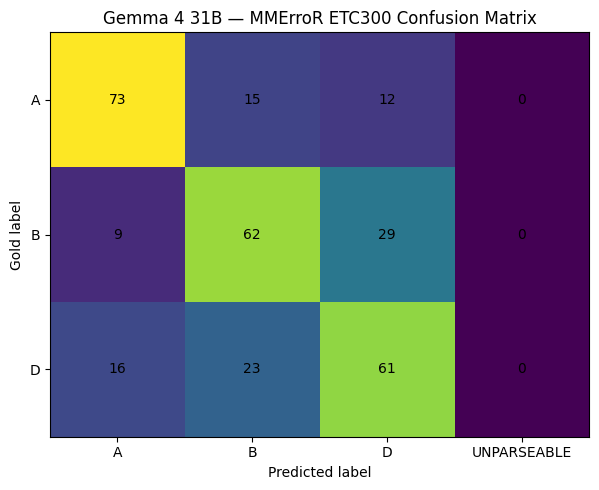

Saved: /kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4/plots/confusion_matrix_counts.png


In [18]:
# Cell 18 — confusion matrix including unparseable predictions
confusion_columns = ["A", "B", "D", "UNPARSEABLE"]
confusion_rows = ["A", "B", "D"]

cm_table = pd.DataFrame(
    0,
    index=confusion_rows,
    columns=confusion_columns,
    dtype=int,
)

for gold, pred in zip(y_true, y_pred_primary):
    cm_table.loc[gold, pred] += 1

display(Markdown("### Confusion matrix — counts"))
display(cm_table)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)
im = ax.imshow(cm_table.values)

ax.set_xticks(range(len(confusion_columns)))
ax.set_xticklabels(confusion_columns)
ax.set_yticks(range(len(confusion_rows)))
ax.set_yticklabels(confusion_rows)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Gold label")
ax.set_title("Gemma 4 31B — MMErroR ETC300 Confusion Matrix")

for i in range(len(confusion_rows)):
    for j in range(len(confusion_columns)):
        ax.text(
            j,
            i,
            str(cm_table.iloc[i, j]),
            ha="center",
            va="center",
        )

fig.tight_layout()
confusion_path = PLOTS_DIR / "confusion_matrix_counts.png"
fig.savefig(confusion_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", confusion_path)


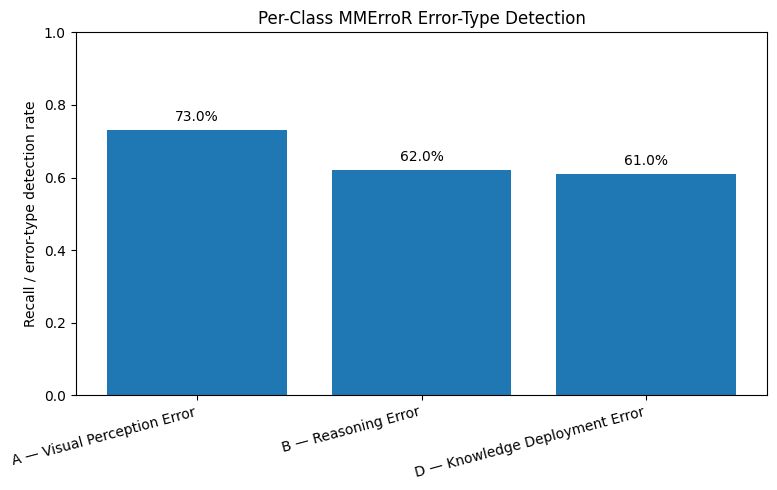

Saved: /kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4/plots/per_class_detection_rate.png


In [19]:
# Cell 19 — per-class recall / error-detection-rate figure
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

x = np.arange(len(per_class))
values = per_class["recall_error_detection_rate"].to_numpy()

ax.bar(x, values)
ax.set_xticks(x)
ax.set_xticklabels(
    per_class["class_letter"] + " — " + per_class["class_name"],
    rotation=15,
    ha="right",
)
ax.set_ylim(0, 1)
ax.set_ylabel("Recall / error-type detection rate")
ax.set_title("Per-Class MMErroR Error-Type Detection")

for i, v in enumerate(values):
    ax.text(
        i,
        min(v + 0.025, 0.98),
        f"{100*v:.1f}%",
        ha="center",
    )

fig.tight_layout()
per_class_plot = PLOTS_DIR / "per_class_detection_rate.png"
fig.savefig(per_class_plot, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", per_class_plot)


In [20]:
# Cell 20 — latency, token, and thinking diagnostics
diagnostics = {
    "n": int(len(results_df)),
    "mean_latency_s": float(results_df["latency_s"].dropna().mean()),
    "median_latency_s": float(results_df["latency_s"].dropna().median()),
    "p90_latency_s": float(results_df["latency_s"].dropna().quantile(0.90)),
    "mean_prompt_tokens": float(results_df["prompt_tokens"].dropna().mean()),
    "mean_completion_tokens": float(results_df["completion_tokens"].dropna().mean()),
    "median_completion_tokens": float(results_df["completion_tokens"].dropna().median()),
    "p90_completion_tokens": float(results_df["completion_tokens"].dropna().quantile(0.90)),
    "max_completion_tokens_observed": (
        int(results_df["completion_tokens"].dropna().max())
        if results_df["completion_tokens"].notna().any()
        else None
    ),
    "reasoning_tokens_exposed_for_n": int(results_df["reasoning_tokens"].notna().sum()),
    "mean_reasoning_tokens_when_exposed": (
        float(results_df["reasoning_tokens"].dropna().mean())
        if results_df["reasoning_tokens"].notna().any()
        else None
    ),
    "finish_reason_counts": (
        results_df["finish_reason"].fillna("NULL").value_counts().to_dict()
    ),
    "attempt_used_counts": (
        results_df["attempt_used"].fillna(-1).astype(int).value_counts().sort_index().to_dict()
    ),
}

display(Markdown("### Efficiency and thinking diagnostics"))
display(pd.DataFrame([diagnostics]))


### Efficiency and thinking diagnostics

,n,mean_latency_s,median_latency_s,p90_latency_s,mean_prompt_tokens,mean_completion_tokens,median_completion_tokens,p90_completion_tokens,max_completion_tokens_observed,reasoning_tokens_exposed_for_n,mean_reasoning_tokens_when_exposed,finish_reason_counts,attempt_used_counts
0,300,78.998299,43.233332,227.306257,966.53,2695.176667,1414.0,7904.2,14213,300,2347.663333,{'STOP': 300},"{1: 296, 2: 4}"


## 10. Statistical interpretation

The selected dataset is deliberately **balanced across the three retained ground-truth error types**, so the headline strict accuracy is not intended to estimate the natural prevalence-weighted performance on the full MMErroR release.

Report the result as:

> **Gemma 4 31B achieved X% strict error-type classification accuracy on a balanced 300-sample MMErroR subset containing 100 Visual Perception, 100 Reasoning, and 100 Knowledge Deployment errors, with Question Comprehension examples excluded from the test set. The prediction space was restricted to the three retained classes A/B/D.**

Do **not** report this number as the official full-MMErroR leaderboard score, because:

1. only 300/1997 examples are evaluated;
2. C-ground-truth examples are excluded;
3. the class prevalence is intentionally rebalanced;
4. Gemma 4 31B is evaluated with thinking enabled and a 32,768-token generation budget.

The official MMErroR full-dataset ETC result remains a different experimental condition.


In [21]:
# Cell 21 — write final/partial artifacts
results_df.to_csv(
    RESULTS_CSV,
    index=False,
)

summary = {
    **headline,
    **bootstrap_summary,
    "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "model": MODEL,
    "api_provider": API_PROVIDER,
    "api_tier": API_TIER,
    "thinking_level": "high",
    "dataset_source": DATASET_SOURCE,
    "dataset_parquet_sha256": DATASET_SOURCE_SHA256,
    "selection_manifest_sha256": SELECTION_MANIFEST_SHA256,
    "prompt_sha256": PROMPT_SHA256,
    "excluded_gold_label": LABEL_C,
    "selected_gold_counts": selected_df["label"].value_counts().to_dict(),
    "prediction_space": ["A", "B", "D"],
    "thinking_enabled": THINKING_ENABLED,
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "top_k": TOP_K,
    "request_seed": REQUEST_SEED,
    "max_tokens": MAX_TOKENS,
    "efficiency_diagnostics": diagnostics,
    "confusion_matrix_counts": {
        row: {
            col: int(cm_table.loc[row, col])
            for col in cm_table.columns
        }
        for row in cm_table.index
    },
}

SUMMARY_JSON.write_text(
    json.dumps(
        summary,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print("Saved:", RESULTS_CSV)
print("Saved:", SUMMARY_JSON)
print("Saved:", PER_CLASS_CSV)
print("Saved:", DOMAIN_CSV)
print("Saved:", SUBDOMAIN_CSV)


Saved: /kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4/results_300.csv
Saved: /kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4/summary_metrics.json
Saved: /kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4/per_class_metrics.csv
Saved: /kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4/accuracy_by_domain.csv
Saved: /kaggle/working/gemma4_31b_mmerror_etc300_noqce_abd_google_free_tier_local_parquet_v4/accuracy_by_subdomain.csv


In [22]:
# Cell 22 — automatically generate publication-ready Methods text
methods_text = f"""
Gemma 4 31B MMErroR error-type classification protocol

We evaluated gemma-4-31b-it through Google's Gemini Developer API using a
Google AI Studio Free-tier project on a fixed 300-sample subset of the
MMErroR benchmark (Shi et al., ACL 2026). The source dataset was loaded
without network download from the attached Kaggle Parquet file
{DATASET_SOURCE}. The exact Parquet bytes were bound by SHA-256
{DATASET_SOURCE_SHA256}. The local source was validated to contain
1,997 examples with the expected error-type counts: 636 Visual Perception
Error, 234 Reasoning Error, 247 Question Comprehension Error, and 880
Knowledge Deployment Error examples.

Per the study design, all ground-truth Question Comprehension Error examples
were excluded prior to sampling. The evaluation subset contained exactly
100 Visual Perception Error, 100 Reasoning Error, and 100 Knowledge
Deployment Error examples (N=300). Within each retained error type,
top-level domain quotas were assigned proportionally using Hamilton's
largest-remainder method. Items within each label-domain stratum were selected
by deterministic SHA-256 ranking using selection seed {SELECTION_SEED}.
Evaluation order was independently fixed by SHA-256 ranking using order seed
{ORDER_SEED}. The resulting input manifest SHA-256 was
{SELECTION_MANIFEST_SHA256}.

The model was evaluated in an adapted Error Type Classification (ETC)
condition. Each request followed the frozen prompt order: task description first, then the
image, question, erroneous reasoning chain, three-class taxonomy, and decision instructions. The model was informed that exactly
one error was present and was given the three retained error categories: (A) Visual Perception Error, (B) Reasoning Error, and (D) Knowledge Deployment Error. Question Comprehension Error was excluded both from the selected ground-truth examples and from the judge's prediction choices. The correct answer, ground-truth error label,
domain, subdomain, and question identifier were not included in the request.

Gemma 4 native thinking was enabled through Google's documented Gemini API
configuration thinkingLevel="high". Gemma 4 exposes thinking as an ON/OFF
control in this API, with "high" enabling and "minimal" disabling it; no
NVIDIA-specific chat-template parameter or undocumented reasoning-effort knob
was used. The maximum output budget was 32,768 tokens. Because this run was designed
as an accuracy-first judge evaluation rather than a temperature-0 replication,
decoding followed Google's documented Gemma 4 best-practice sampling
configuration: temperature={TEMPERATURE}, topP={TOP_P}, and topK={TOP_K}.
A fixed request seed of {REQUEST_SEED} was supplied through Google's documented
generation configuration as an additional reproducibility control. Requests
were non-streaming and executed sequentially through the Gemini Developer API
v1beta generateContent endpoint.

Google responses were parsed by separating candidate parts marked thought=true
from ordinary final-answer parts. Thought text, when exposed, was archived only
for diagnostics; the primary prediction parser operated exclusively on the
non-thought final answer. Token accounting used usageMetadata, including
promptTokenCount, candidatesTokenCount, thoughtsTokenCount, and totalTokenCount
when returned by the service.

Primary scoring required the last non-empty line of the retained HTTP-200 model
response to exactly match "Final label: X", where X was A, B, or D. Strict
parse failures were counted as incorrect. Valid HTTP-200 responses were never
retried on the basis of content, correctness, formatting, or truncation;
retries were restricted to transport failures, rate limiting, and retryable
HTTP server errors. The exact prompt was cryptographically bound by SHA-256
{PROMPT_SHA256}.

The primary outcome was strict error-type classification accuracy. We also
reported a Wilson 95% confidence interval, macro-F1 over the three retained
ground-truth classes, balanced accuracy, Matthews correlation coefficient,
Cohen's kappa, per-class recall, domain-level accuracy, strict-format
compliance, truncation rate,
latency, and token usage. Stratified bootstrap confidence intervals used
{N_BOOTSTRAP} replicates with bootstrap seed {BOOTSTRAP_SEED}.

Run status: {STATUS}
"""

METHODS_TXT.write_text(
    methods_text.strip() + "\n",
    encoding="utf-8",
)

print(methods_text)



Gemma 4 31B MMErroR error-type classification protocol

We evaluated gemma-4-31b-it through Google's Gemini Developer API using a
Google AI Studio Free-tier project on a fixed 300-sample subset of the
MMErroR benchmark (Shi et al., ACL 2026). The source dataset was loaded
without network download from the attached Kaggle Parquet file
/kaggle/input/notebooks/vernvern/glimmer/mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet. The exact Parquet bytes were bound by SHA-256
3d4c3bded9ce04336c878da6bc1e139362fc915818dcfc72380bfc24eb097edb. The local source was validated to contain
1,997 examples with the expected error-type counts: 636 Visual Perception
Error, 234 Reasoning Error, 247 Question Comprehension Error, and 880
Knowledge Deployment Error examples.

Per the study design, all ground-truth Question Comprehension Error examples
were excluded prior to sampling. The evaluation subset contained exactly
100 Visual Perception Error, 100 Reasoning Error, and 100 Knowledge
Deployment E

In [23]:
# Cell 23 — README_RESULTS.md and citation bundle
def pct(x):
    return "N/A" if x is None else f"{100*float(x):.2f}%"

readme = f"""# {EXPERIMENT_ID}

## Status
**{STATUS}**

## Core result
- Completed: **{len(results_df)}/{EXPECTED_N}**
- Strict accuracy: **{pct(strict_accuracy)}**
- Wilson 95% CI: **[{pct(ci_low)}, {pct(ci_high)}]**
- Macro-F1 (A/B/D): **{macro_f1:.4f}**
- Balanced accuracy: **{pct(balanced_acc)}**
- Strict parse rate: **{pct(parse_rate)}**
- Truncation rate: **{pct(truncation_rate)}**

## Protocol
- Model: `{MODEL}`
- Provider: `{API_PROVIDER}`
- Intended tier: `{API_TIER}`
- Native thinking: `ON (thinkingLevel=high)`
- Temperature: `{TEMPERATURE}`
- Top-p: `{TOP_P}`
- Top-k: `{TOP_K}`
- Request seed: `{REQUEST_SEED}`
- Max output tokens: `{MAX_TOKENS}`
- Dataset source: `{DATASET_SOURCE}`
- Dataset Parquet SHA-256: `{DATASET_SOURCE_SHA256}`
- Selection manifest SHA: `{SELECTION_MANIFEST_SHA256}`
- Prompt SHA: `{PROMPT_SHA256}`
- Ground-truth C samples included: `NO`
- Prediction choices: `A/B/D`

## Selected gold distribution
- A Visual Perception Error: 100
- B Reasoning Error: 100
- D Knowledge Deployment Error: 100

## Canonical files
- `selected_300_manifest.csv`
- `selection_audit.json`
- `PROMPT.txt`
- `run_manifest.json`
- `raw_results.jsonl`
- `api_events.jsonl`
- `results_300.csv`
- `summary_metrics.json`
- `per_class_metrics.csv`
- `accuracy_by_domain.csv`
- `accuracy_by_subdomain.csv`
- `METHODS.txt`
- `CITATION.bib`
- `plots/confusion_matrix_counts.png`
- `plots/per_class_detection_rate.png`

Only a `FINAL_300_OF_300` run should be quoted as the final paper result.
"""

README_RESULTS.write_text(
    readme,
    encoding="utf-8",
)

bibtex = r"""@inproceedings{shi-etal-2026-mmerror,
  title = {{MME}rro{R}: A Benchmark for Erroneous Reasoning in Vision-Language Models},
  author = {Shi, Yang and Xie, Yifeng and Guo, Minzhe and Lu, Liangsi and Huang, Mingxuan and Wang, Jingchao and Zhu, Zhihong and Xu, Boyan and Huang, Zhiqi},
  booktitle = {Proceedings of the 64th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)},
  year = {2026},
  address = {San Diego, California, United States},
  publisher = {Association for Computational Linguistics},
  pages = {44973--44986},
  doi = {10.18653/v1/2026.acl-long.2083},
  url = {https://aclanthology.org/2026.acl-long.2083/}
}
"""

CITATION_BIB.write_text(
    bibtex,
    encoding="utf-8",
)

print(readme)


# MMErroR-ETC300-NoQCE__Gemma4-31B-IT__ThinkingON__GoogleFreeTier__LocalParquet__BestSampling__Temp1_TopP095_TopK64__MaxTok32768__Seed42__v4

## Status
**FINAL_300_OF_300**

## Core result
- Completed: **300/300**
- Strict accuracy: **65.33%**
- Wilson 95% CI: **[59.78%, 70.49%]**
- Macro-F1 (A/B/D): **0.6538**
- Balanced accuracy: **65.33%**
- Strict parse rate: **100.00%**
- Truncation rate: **0.00%**

## Protocol
- Model: `gemma-4-31b-it`
- Provider: `Google Gemini Developer API`
- Intended tier: `Google AI Studio Free tier`
- Native thinking: `ON (thinkingLevel=high)`
- Temperature: `1.0`
- Top-p: `0.95`
- Top-k: `64`
- Request seed: `42`
- Max output tokens: `32768`
- Dataset source: `/kaggle/input/notebooks/vernvern/glimmer/mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet`
- Dataset Parquet SHA-256: `3d4c3bded9ce04336c878da6bc1e139362fc915818dcfc72380bfc24eb097edb`
- Selection manifest SHA: `857235b6fab021251a662ab0bf92fe7ec0158fd8480cb0bf5e479cd82e119f5a`
- Prompt SHA: `6c

## 11. Reporting checklist

Before citing the result in the paper, verify that the final notebook output shows:

```text
Status                         = FINAL_300_OF_300
Completed                      = 300/300
Selected gold labels           = A:100, B:100, D:100
Ground-truth C count           = 0
Provider                       = Google Gemini Developer API
Account tier                   = Google AI Studio Free tier
Thinking enabled               = True (thinkingLevel=high)
Temperature                    = 1.0
Top-p                          = 0.95
Top-k                          = 64
Request seed                   = 42
Max output tokens              = 32768
Strict parser                  = enabled
Content-based retries          = none
Dataset Parquet SHA-256        = recorded
Selection manifest SHA         = recorded
Prompt SHA                     = recorded
```

### Recommended paper wording

Do not write:

> “Gemma 4 31B scores X% on MMErroR.”

Write:

> “On our balanced 300-sample MMErroR ETC subset excluding ground-truth Question Comprehension Error instances, Gemma 4 31B achieved X% strict error-type classification accuracy with native thinking enabled. The prediction space was restricted to the three retained classes A/B/D.”

This wording prevents the subset score from being confused with the official full-dataset MMErroR leaderboard.


In [24]:
# Cell 24 — final artifact inventory and terminal scientific gates
assert len(selected_df) == 300
assert selected_df["question_id"].nunique() == 300
assert LABEL_C not in set(selected_df["label"])
assert selected_df["label"].value_counts().to_dict() == {
    LABEL_A: 100,
    LABEL_B: 100,
    LABEL_D: 100,
}

assert THINKING_ENABLED is True
assert TEMPERATURE == 1.0
assert TOP_P == 0.95
assert TOP_K == 64
assert REQUEST_SEED == 42
assert MAX_TOKENS == 32768

assert hashlib.sha256(
    PROMPT_CANONICAL.encode("utf-8")
).hexdigest() == PROMPT_SHA256

assert SELECTION_MANIFEST_SHA256 == hashlib.sha256(
    json.dumps(
        manifest_records,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

print("=" * 96)
print("FINAL SCIENTIFIC GATES: PASS")
print("=" * 96)
print("Run status             :", STATUS)
print("Dataset Parquet SHA256 :", DATASET_SOURCE_SHA256)
print("Selection manifest SHA :", SELECTION_MANIFEST_SHA256)
print("Prompt SHA             :", PROMPT_SHA256)
print("Experiment signature   :", EXPERIMENT_SIGNATURE)
print("Thinking               :", THINKING_ENABLED)
print("Temperature            :", TEMPERATURE)
print("Top-p                  :", TOP_P)
print("Top-k                  :", TOP_K)
print("Request seed           :", REQUEST_SEED)
print("Max output tokens      :", MAX_TOKENS)
print("Gold C samples         :", int((selected_df["label"] == LABEL_C).sum()))
print("Prediction space       : A/B/D")
print("Completed model calls  :", len(results_df), "/", EXPECTED_N)

print("\nArtifact inventory:")
for p in sorted(WORKDIR.rglob("*")):
    if p.is_file():
        rel = p.relative_to(WORKDIR)
        print(
            f" - {rel} "
            f"({p.stat().st_size / 1024:.1f} KiB)"
        )


FINAL SCIENTIFIC GATES: PASS
Run status             : FINAL_300_OF_300
Dataset Parquet SHA256 : 3d4c3bded9ce04336c878da6bc1e139362fc915818dcfc72380bfc24eb097edb
Selection manifest SHA : 857235b6fab021251a662ab0bf92fe7ec0158fd8480cb0bf5e479cd82e119f5a
Prompt SHA             : 6cf9065b6c1173c8910bf7f7c1c27527799ace6168e71904cedf215e8b31f8c7
Experiment signature   : f86cb417c3d9050aefb2c00566c2e6a3e15c0b0978b87cf916a0eb5e8c6d0f61
Thinking               : True
Temperature            : 1.0
Top-p                  : 0.95
Top-k                  : 64
Request seed           : 42
Max output tokens      : 32768
Gold C samples         : 0
Prediction space       : A/B/D
Completed model calls  : 300 / 300

Artifact inventory:
 - CITATION.bib (0.7 KiB)
 - METHODS.txt (4.3 KiB)
 - PROMPT.txt (2.3 KiB)
 - README_RESULTS.md (1.7 KiB)
 - accuracy_by_domain.csv (0.6 KiB)
 - accuracy_by_subdomain.csv (2.1 KiB)
 - api_events.jsonl (63.0 KiB)
 - mmerror_source/data/images/MMErroR_00001.png (62.2 KiB)
 - mmerr

## 12. Interpretation boundaries

This experiment evaluates **error-type classification**, not first-error localization and not the faithfulness of the model's hidden reasoning.

Google response parts marked `thought=true`, when exposed by the endpoint, are archived only as a diagnostic artifact. The primary score depends solely on the final predicted MMErroR error label.

Because all MMErroR chains contain an injected error, this experiment should not be interpreted as measuring the model's false-positive rate on clean reasoning chains. It measures attribution of a known-present reasoning error under the ETC setup.
